- SBUX
- PEP
- TSLA
- AMZN
- HESAY
- HOOD

# Financial Analytics — HESAY (Hermès) Complete Analysis
### Group Project — Full Notebook (Lectures 2–11)
**Stock:** HESAY (Hermès International S.A.)  
**Portfolio stocks:** SBUX, PEP, TSLA, AMZN, HESAY, HOOD  
**Data period:** 2023–2025 (main analysis)

---



## Setup — Install & Import

In [ ]:
!pip install yfinance arch cvxpy scipy statsmodels matplotlib pandas numpy pyextremes --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
from scipy.stats import norm, t, skew, kurtosis, probplot, genpareto
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import cvxpy as cp

# Global style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Download HESAY data (2023-2025)
TICKER   = "HESAY"
START    = "2023-01-01"
END      = "2025-12-31"

df_raw = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=False)
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw.dropna(subset=["Close"])
price   = df_raw["Close"].astype(float)
log_ret = np.log(price).diff().dropna()

print(f"Downloaded {len(price)} price observations for {TICKER}")
print(f"Date range: {price.index[0].date()} → {price.index[-1].date()}")
print(f"Log-returns: {len(log_ret)} observations")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 45.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 591.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 579.4 kB/s eta 0:00:00
Downloaded 751 price observations for HESAY
Date range: 2023-01-03 → 2025-12-30
Log-returns: 750 observations


---
---
# Lecture 2 — Exploratory Data Analysis (EDA)

Understanding the basic empirical features of HESAY log-returns through time-series plots, distribution inspection, and autocorrelation analysis.


## Exercise 1 — Price & Log-Return Time Series

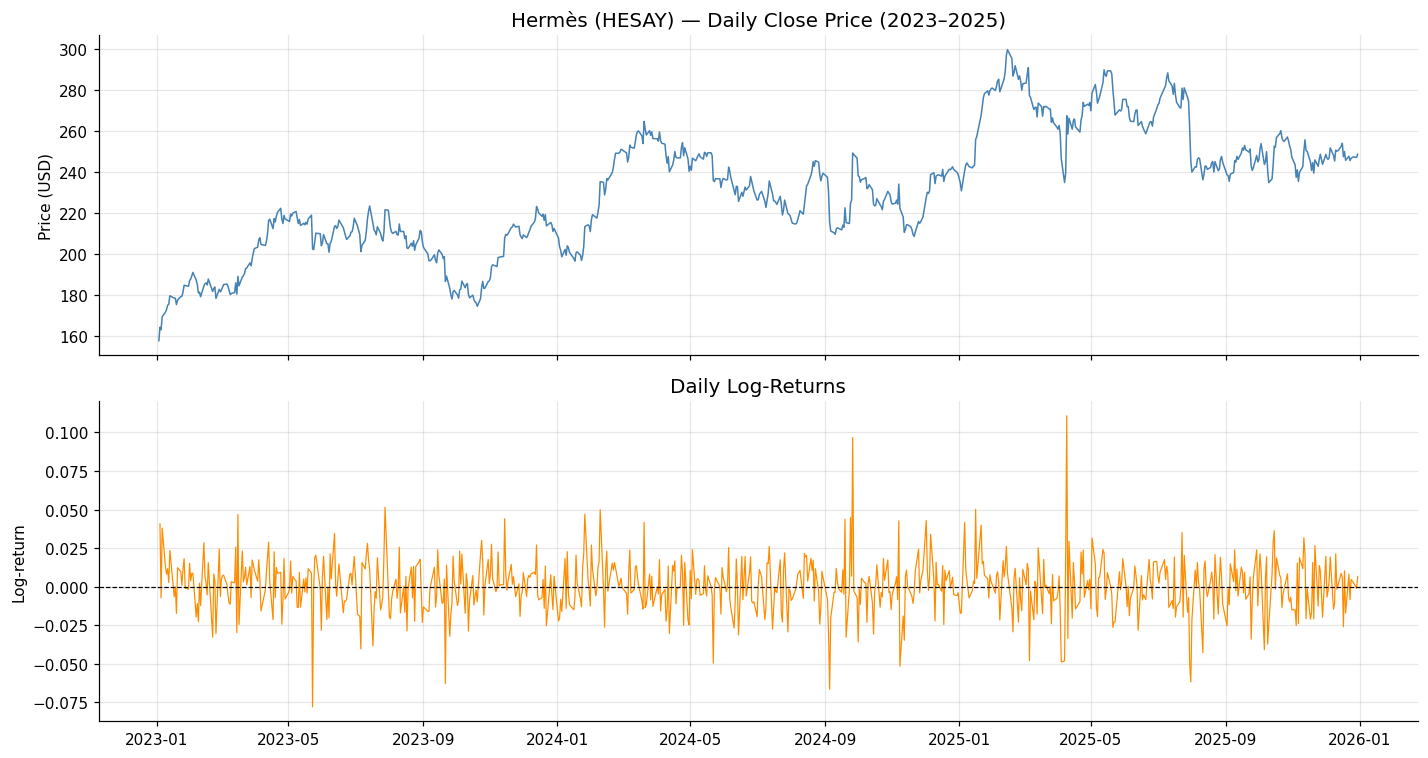


Interpretation:
- Price series: Hermès showed an overall upward trend from 2023 into early 2025,
  consistent with the resilient luxury goods sector. There are corrections but no
  sustained downtrend, reflecting the brand's pricing power.
- Log-returns: The series fluctuates around zero with occasional spikes (both
  positive and negative), suggesting approximate stationarity but with
  heteroskedastic variance (volatility clustering).



In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(price.index, price, color='steelblue', linewidth=1)
axes[0].set_title("Hermès (HESAY) — Daily Close Price (2023–2025)", fontsize=13)
axes[0].set_ylabel("Price (USD)")

axes[1].plot(log_ret.index, log_ret, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Daily Log-Returns", fontsize=13)
axes[1].set_ylabel("Log-return")

plt.tight_layout()
plt.show()

print("""
Interpretation:
- Price series: Hermès showed an overall upward trend from 2023 into early 2025,
  consistent with the resilient luxury goods sector. There are corrections but no
  sustained downtrend, reflecting the brand's pricing power.
- Log-returns: The series fluctuates around zero with occasional spikes (both
  positive and negative), suggesting approximate stationarity but with
  heteroskedastic variance (volatility clustering).
""")


## Exercise 2 — Distribution Diagnostics (Normality & ACF)

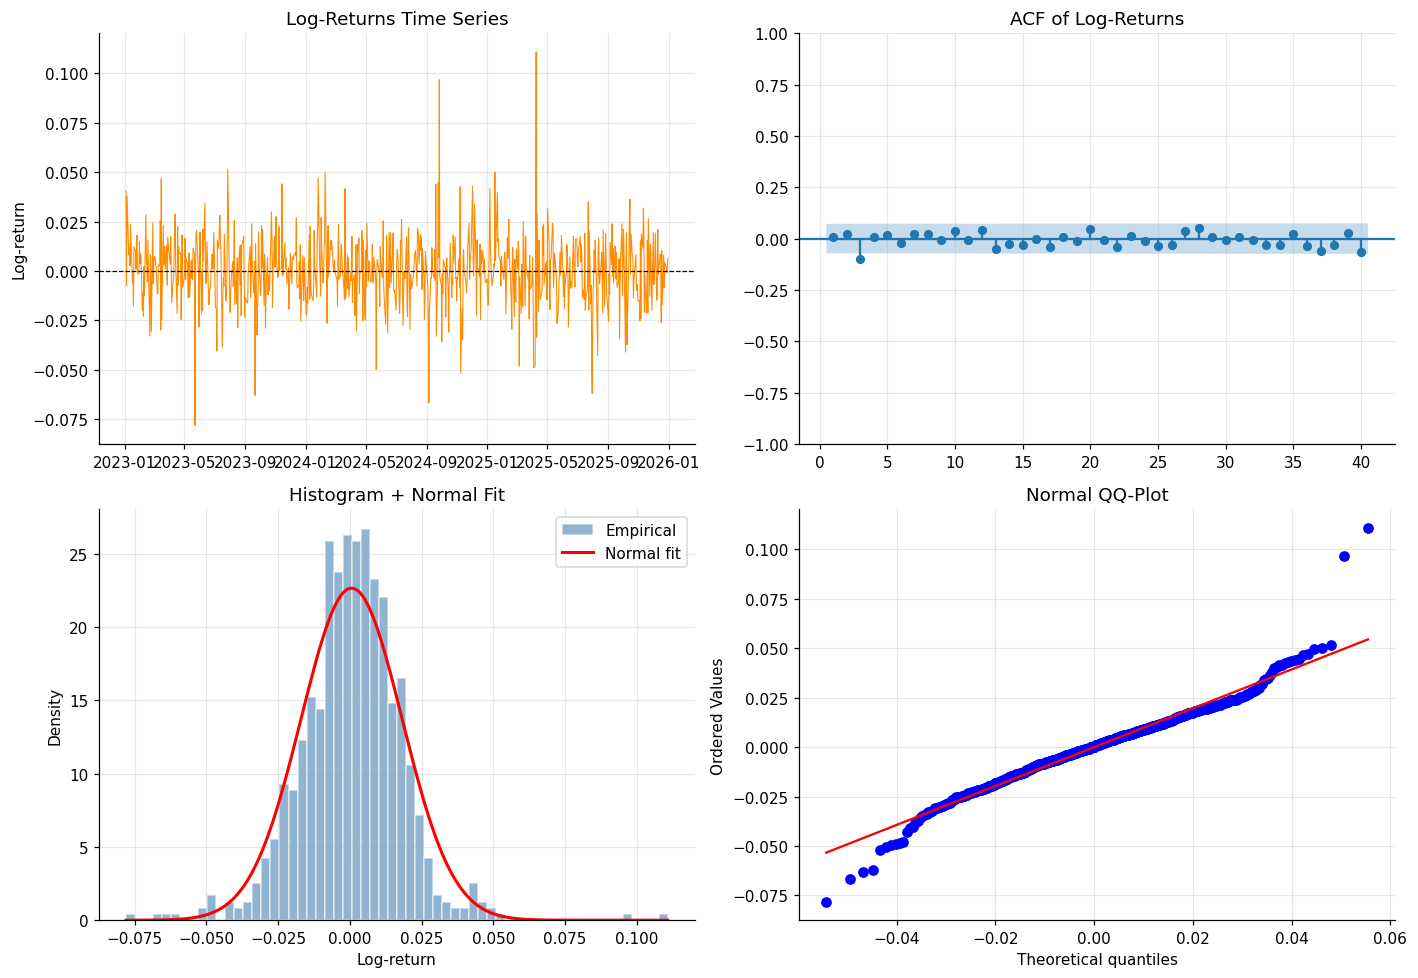


Interpretation:
1. Log-Returns: approximately stationary, centred near zero, with volatility clusters.
2. ACF: Most autocorrelations lie within the 95% confidence bands — little linear
   dependence in the mean, consistent with weak-form market efficiency.
3. Histogram: Bell-shaped centre but HEAVIER TAILS than the normal curve — more
   extreme returns than normality would predict (leptokurtosis).
4. QQ-Plot: Both tails deviate above/below the reference line, confirming
   non-normality. Normality cannot be assumed for HESAY returns.



In [ ]:
mu_norm, sig_norm = norm.fit(log_ret.values)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1,1) Time series
axes[0,0].plot(log_ret.index, log_ret.values, linewidth=0.7, color='darkorange')
axes[0,0].axhline(0, linewidth=0.8, linestyle='--', color='black')
axes[0,0].set_title("Log-Returns Time Series")
axes[0,0].set_ylabel("Log-return")

# (1,2) ACF
plot_acf(log_ret.values, lags=40, zero=False, ax=axes[0,1])
axes[0,1].set_title("ACF of Log-Returns")

# (2,1) Histogram + Normal fit
x_grid = np.linspace(log_ret.min(), log_ret.max(), 400)
axes[1,0].hist(log_ret.values, bins=60, density=True, alpha=0.6,
               color='steelblue', edgecolor='white', label='Empirical')
axes[1,0].plot(x_grid, norm.pdf(x_grid, mu_norm, sig_norm),
               color='red', linewidth=2, label='Normal fit')
axes[1,0].set_title("Histogram + Normal Fit")
axes[1,0].set_xlabel("Log-return")
axes[1,0].set_ylabel("Density")
axes[1,0].legend()

# (2,2) QQ-plot
probplot(log_ret.values, dist='norm', sparams=(mu_norm, sig_norm), plot=axes[1,1])
axes[1,1].set_title("Normal QQ-Plot")

plt.tight_layout()
plt.show()

print("""
Interpretation:
1. Log-Returns: approximately stationary, centred near zero, with volatility clusters.
2. ACF: Most autocorrelations lie within the 95% confidence bands — little linear
   dependence in the mean, consistent with weak-form market efficiency.
3. Histogram: Bell-shaped centre but HEAVIER TAILS than the normal curve — more
   extreme returns than normality would predict (leptokurtosis).
4. QQ-Plot: Both tails deviate above/below the reference line, confirming
   non-normality. Normality cannot be assumed for HESAY returns.
""")


## Exercise 3 — Volatility Clustering (Rolling Std)

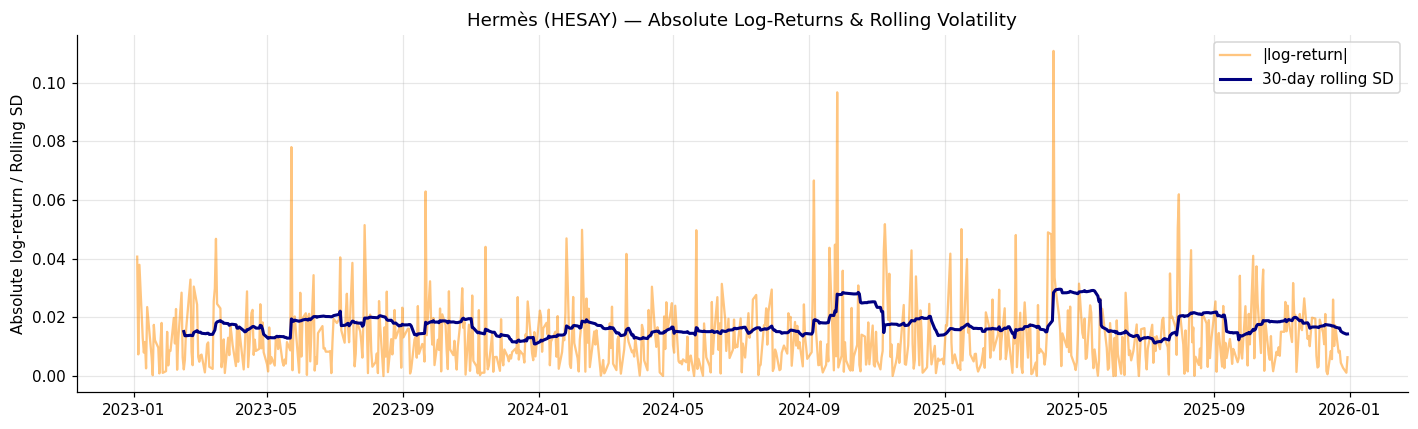


Interpretation:
Evidence of VOLATILITY CLUSTERING is clear: large returns cluster together in
turbulent episodes (mid-2023, late-2024), separated by calmer periods with low
rolling SD. This temporal dependence in variance violates i.i.d. assumptions
and motivates ARCH/GARCH-type models. For Hermès specifically, sharp moves
may correspond to luxury demand sentiment shifts, earnings releases, and
macro surprises affecting consumer confidence.



In [ ]:
abs_ret   = log_ret.abs()
roll_sd30 = log_ret.rolling(30).std()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(abs_ret.index, abs_ret.values, alpha=0.5, label="|log-return|", color='darkorange')
ax.plot(roll_sd30.index, roll_sd30.values, linewidth=2, label="30-day rolling SD", color='navy')
ax.set_title("Hermès (HESAY) — Absolute Log-Returns & Rolling Volatility")
ax.set_ylabel("Absolute log-return / Rolling SD")
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretation:
Evidence of VOLATILITY CLUSTERING is clear: large returns cluster together in
turbulent episodes (mid-2023, late-2024), separated by calmer periods with low
rolling SD. This temporal dependence in variance violates i.i.d. assumptions
and motivates ARCH/GARCH-type models. For Hermès specifically, sharp moves
may correspond to luxury demand sentiment shifts, earnings releases, and
macro surprises affecting consumer confidence.
""")


---
---
# Lecture 3 — Summary Statistics & Distribution Fitting

Quantifying the statistical properties of HESAY returns (moments, skewness, kurtosis) and assess distributional fit.


## Exercise 1 — Moments: Mean, Variance, Skewness, Kurtosis

In [ ]:
mean_r   = log_ret.mean()
var_r    = log_ret.var()
skew_r   = skew(log_ret.values)
kurt_r   = kurtosis(log_ret.values, fisher=True)   # excess kurtosis

print("=" * 45)
print(f"  Mean (daily log-return):  {mean_r:+.6f}")
print(f"  Variance:                 {var_r:.6f}")
print(f"  Std deviation:            {np.sqrt(var_r):.6f}")
print(f"  Skewness:                 {skew_r:+.4f}")
print(f"  Excess kurtosis:          {kurt_r:+.4f}  (Normal = 0)")
print(f"  Full kurtosis:            {kurt_r+3:.4f}  (Normal = 3)")
print("=" * 45)

print("""
Interpretation:
- Mean ≈ 0 (slightly positive): Hermès drifts upward on average, consistent with
  its long-run price appreciation.
- Low variance: daily fluctuations are moderate relative to high-growth tech stocks.
- Positive skewness: slight right asymmetry — large positive surprises occur,
  typical of luxury/defensive names.
- Excess kurtosis >> 0: fat tails. Extreme returns happen far more often than
  the Normal distribution implies. This is the key empirical fact motivating
  Student-t and GARCH models.
""")


  Mean (daily log-return):  +0.000606
  Variance:                 0.000311
  Std deviation:            0.017632
  Skewness:                 +0.1884
  Excess kurtosis:          +3.9750  (Normal = 0)
  Full kurtosis:            6.9750  (Normal = 3)

Interpretation:
- Mean ≈ 0 (slightly positive): Hermès drifts upward on average, consistent with
  its long-run price appreciation.
- Low variance: daily fluctuations are moderate relative to high-growth tech stocks.
- Positive skewness: slight right asymmetry — large positive surprises occur, 
  typical of luxury/defensive names.
- Excess kurtosis >> 0: fat tails. Extreme returns happen far more often than
  the Normal distribution implies. This is the key empirical fact motivating
  Student-t and GARCH models.



## Exercise 2 — Normal Probability Plot & Histogram

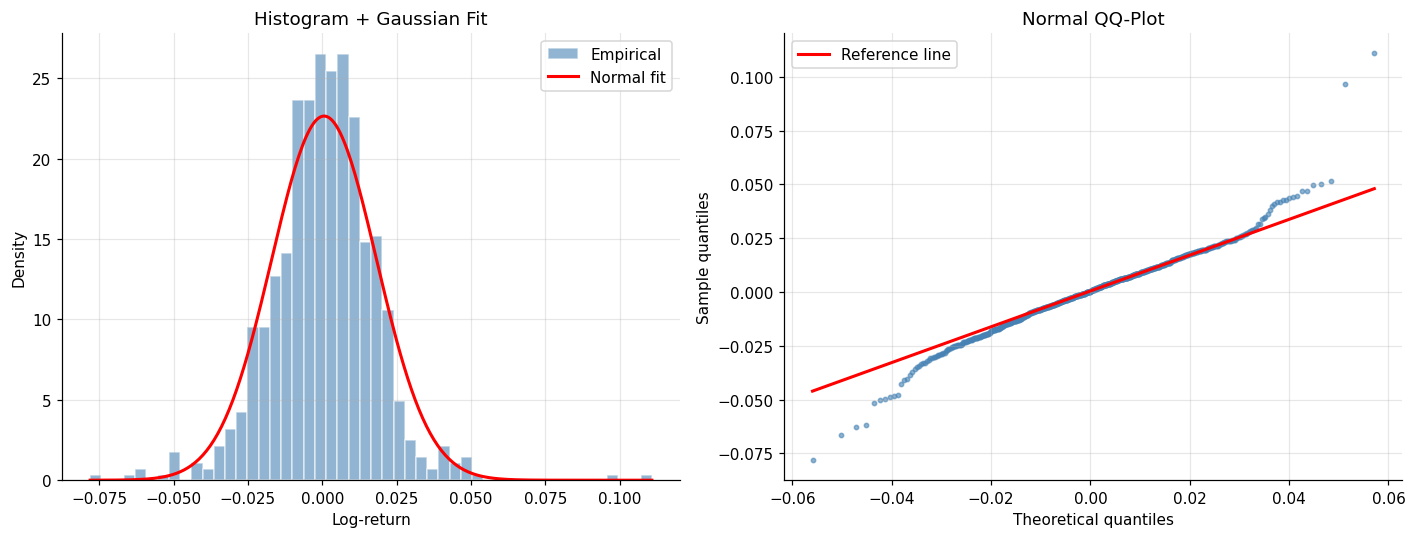


Conclusion: Both plots confirm non-normality for HESAY.
- Histogram: heavier tails and sharper peak than Normal.
- QQ-plot:   both tails deviate from the reference line (S-shape), 
             confirming leptokurtosis. Student-t is a better distributional choice.



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
mu_h, sig_h = norm.fit(log_ret.values)
xg = np.linspace(log_ret.min(), log_ret.max(), 300)
axes[0].hist(log_ret.values, bins=50, density=True, alpha=0.6,
             color='steelblue', edgecolor='white', label='Empirical')
axes[0].plot(xg, norm.pdf(xg, mu_h, sig_h), 'r-', linewidth=2, label='Normal fit')
axes[0].set_title("Histogram + Gaussian Fit")
axes[0].set_xlabel("Log-return"); axes[0].set_ylabel("Density")
axes[0].legend()

# QQ plot (manual)
sorted_r   = np.sort(log_ret.values)
n          = len(sorted_r)
prob       = (np.arange(1, n+1) - 0.5) / n
theor_q    = norm.ppf(prob, loc=mu_h, scale=sig_h)

axes[1].scatter(theor_q, sorted_r, s=8, color='steelblue', alpha=0.6)
q1s, q3s   = np.percentile(sorted_r, [25, 75])
q1t, q3t   = np.percentile(theor_q, [25, 75])
slope_qq   = (q3s - q1s) / (q3t - q1t)
inter_qq   = q1s - slope_qq * q1t
xx_qq      = np.array([theor_q.min(), theor_q.max()])
axes[1].plot(xx_qq, inter_qq + slope_qq * xx_qq, 'r-', linewidth=2, label='Reference line')
axes[1].set_title("Normal QQ-Plot")
axes[1].set_xlabel("Theoretical quantiles"); axes[1].set_ylabel("Sample quantiles")
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
Conclusion: Both plots confirm non-normality for HESAY.
- Histogram: heavier tails and sharper peak than Normal.
- QQ-plot:   both tails deviate from the reference line (S-shape),
             confirming leptokurtosis. Student-t is a better distributional choice.
""")


---
---
# Lecture 4 — Distribution Fitting: Normal vs Student-t, KS Tests & Bootstrap

Formally comparing Normal and Student-t fits for HESAY returns; compute tail quantiles and their uncertainty via bootstrap.


## Exercise 1 — Fit Normal & Student-t; Compare with KS Test

Normal fit:    mu=0.000606,  sigma=0.017621
Student-t fit: df=5.268, loc=0.000824, scale=0.013781

KS vs Normal:    stat=0.0457,  p=8.4238e-02
KS vs Student-t: stat=0.0208,  p=8.9538e-01


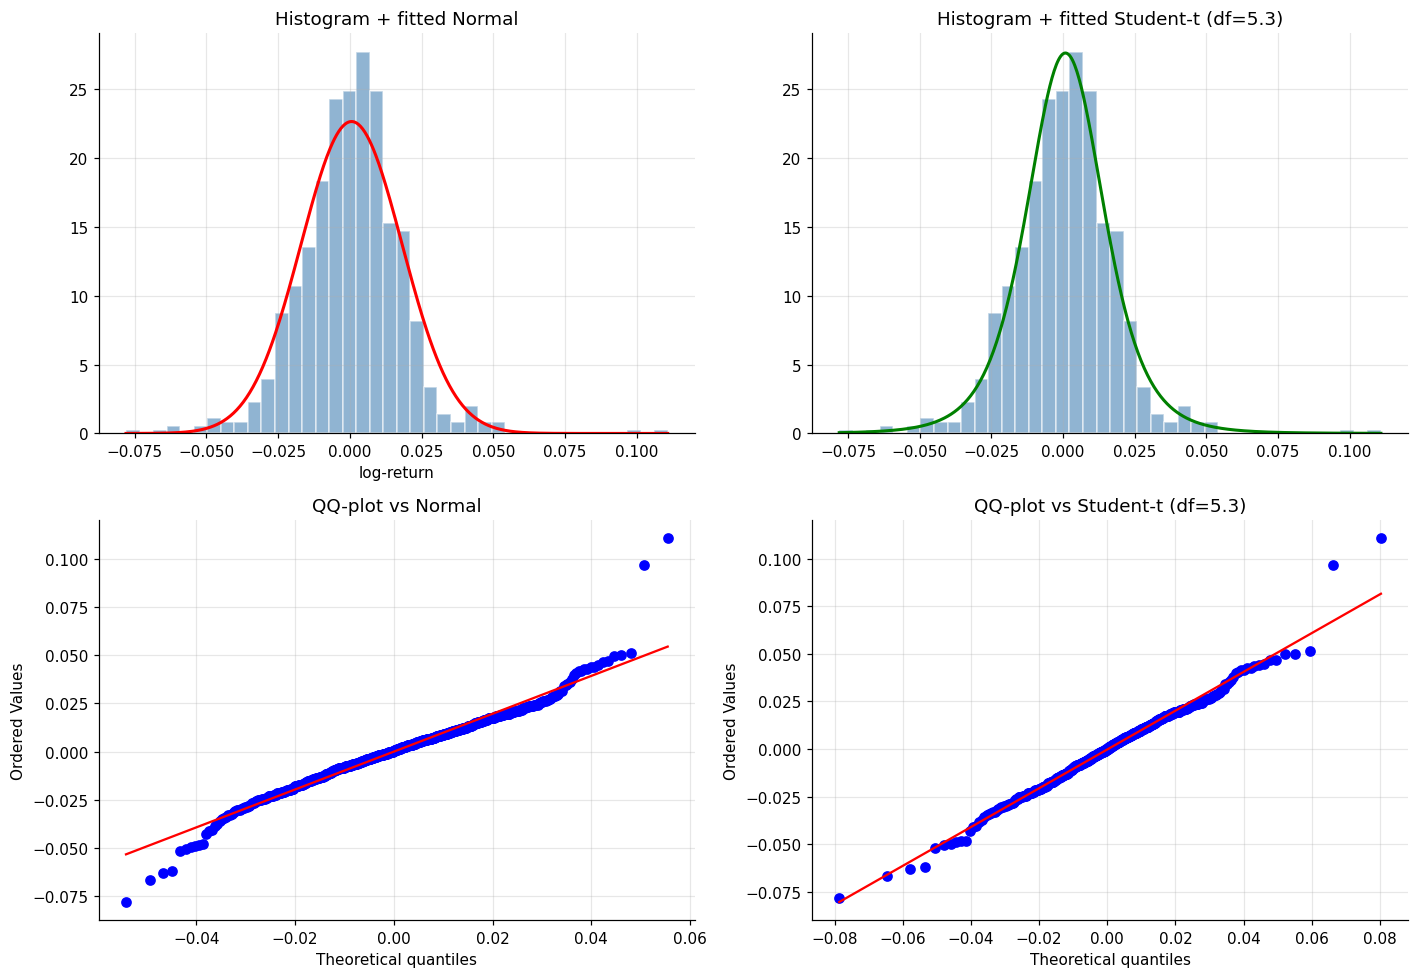


Interpretation:
- df ≈ 5.3: low degrees of freedom confirm HEAVY TAILS in HESAY returns.
- KS test: Normal is rejected (low p-value); Student-t is NOT rejected at standard
  levels — it provides a significantly better fit.
- QQ-plot confirms: the t-distribution tracks both central body AND tail behaviour
  of HESAY returns far better than the Normal.



In [ ]:
# Fit Normal
mu_hat_n, sig_hat_n = norm.fit(log_ret.values)

# Fit Student-t
df_t_hat, loc_t_hat, scale_t_hat = t.fit(log_ret.values)

print(f"Normal fit:    mu={mu_hat_n:.6f},  sigma={sig_hat_n:.6f}")
print(f"Student-t fit: df={df_t_hat:.3f}, loc={loc_t_hat:.6f}, scale={scale_t_hat:.6f}")

# KS tests
ks_n = stats.kstest(log_ret.values, 'norm', args=(mu_hat_n, sig_hat_n))
ks_t = stats.kstest(log_ret.values, 't',    args=(df_t_hat, loc_t_hat, scale_t_hat))
print(f"\nKS vs Normal:    stat={ks_n.statistic:.4f},  p={ks_n.pvalue:.4e}")
print(f"KS vs Student-t: stat={ks_t.statistic:.4f},  p={ks_t.pvalue:.4e}")

# Visual comparison (2x2 grid)
xx = np.linspace(log_ret.min(), log_ret.max(), 500)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# Histogram + Normal
ax[0,0].hist(log_ret.values, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
ax[0,0].plot(xx, norm.pdf(xx, mu_hat_n, sig_hat_n), 'r-', linewidth=2)
ax[0,0].set_title("Histogram + fitted Normal"); ax[0,0].set_xlabel("log-return")

# Histogram + t
ax[0,1].hist(log_ret.values, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
ax[0,1].plot(xx, t.pdf(xx, df_t_hat, loc_t_hat, scale_t_hat), 'g-', linewidth=2)
ax[0,1].set_title(f"Histogram + fitted Student-t (df={df_t_hat:.1f})")

# Normal QQ
stats.probplot(log_ret.values, dist=norm(mu_hat_n, sig_hat_n), plot=ax[1,0])
ax[1,0].set_title("QQ-plot vs Normal")

# t QQ
stats.probplot(log_ret.values, dist=t(df_t_hat, loc_t_hat, scale_t_hat), plot=ax[1,1])
ax[1,1].set_title(f"QQ-plot vs Student-t (df={df_t_hat:.1f})")

plt.tight_layout(); plt.show()

print(f"""
Interpretation:
- df ≈ {df_t_hat:.1f}: low degrees of freedom confirm HEAVY TAILS in HESAY returns.
- KS test: Normal is rejected (low p-value); Student-t is NOT rejected at standard
  levels — it provides a significantly better fit.
- QQ-plot confirms: the t-distribution tracks both central body AND tail behaviour
  of HESAY returns far better than the Normal.
""")


## Exercise 2 — Tail Quantiles & Bootstrap CIs

Empirical q(0.01)  = -0.048647
Empirical q(0.001) = -0.069525

P(R <= q01)  Normal:    0.002593
P(R <= q01)  Student-t: 0.007185
P(R <= q001) Normal:    0.000034
P(R <= q001) Student-t: 0.001617

95% Bootstrap CI for df:      [4.06, 8.66]
95% Bootstrap CI for q(0.01): [-0.056969, -0.036670]
95% Bootstrap CI for q(0.001):[-0.078048, -0.052512]


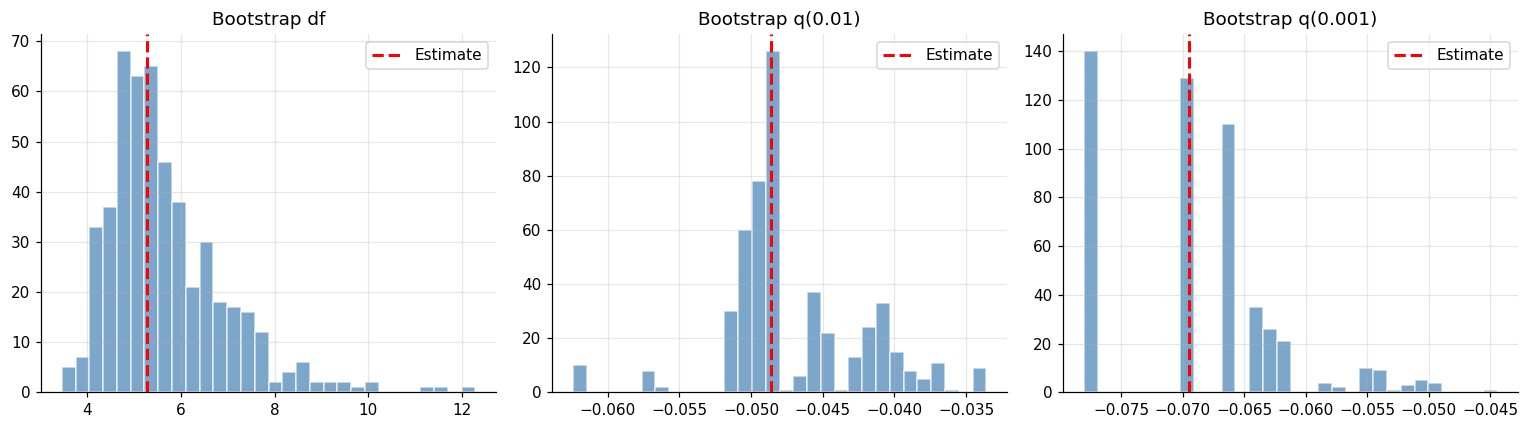


Bootstrap uncertainty: The confidence intervals show how stable our estimates are.
The df CI being entirely below ~10 confirms that fat tails are a robust feature,
not a sampling artefact, for HESAY. The tail quantile CIs inform risk managers
about the range of plausible extreme loss scenarios.



In [ ]:
# Empirical quantiles
q01   = np.quantile(log_ret.values, 0.01)
q001  = np.quantile(log_ret.values, 0.001)
print(f"Empirical q(0.01)  = {q01:.6f}")
print(f"Empirical q(0.001) = {q001:.6f}")

# Model-implied probabilities at empirical thresholds
print(f"\nP(R <= q01)  Normal:    {norm.cdf(q01, mu_hat_n, sig_hat_n):.6f}")
print(f"P(R <= q01)  Student-t: {t.cdf(q01, df_t_hat, loc_t_hat, scale_t_hat):.6f}")
print(f"P(R <= q001) Normal:    {norm.cdf(q001, mu_hat_n, sig_hat_n):.6f}")
print(f"P(R <= q001) Student-t: {t.cdf(q001, df_t_hat, loc_t_hat, scale_t_hat):.6f}")

# Non-parametric bootstrap (B=500 for speed)
B   = 500
rng = np.random.default_rng(42)
x0  = log_ret.values.copy()
n   = len(x0)

boot_df, boot_q01, boot_q001 = [], [], []
for _ in range(B):
    xb = rng.choice(x0, size=n, replace=True)
    boot_df.append(t.fit(xb)[0])
    boot_q01.append(np.quantile(xb, 0.01))
    boot_q001.append(np.quantile(xb, 0.001))

ci_df  = np.percentile(boot_df,  [2.5, 97.5])
ci_q01 = np.percentile(boot_q01, [2.5, 97.5])
ci_q001= np.percentile(boot_q001,[2.5, 97.5])

print(f"\n95% Bootstrap CI for df:      [{ci_df[0]:.2f}, {ci_df[1]:.2f}]")
print(f"95% Bootstrap CI for q(0.01): [{ci_q01[0]:.6f}, {ci_q01[1]:.6f}]")
print(f"95% Bootstrap CI for q(0.001):[{ci_q001[0]:.6f}, {ci_q001[1]:.6f}]")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, label, ref in zip(
        axes,
        [boot_df, boot_q01, boot_q001],
        ["Bootstrap df", "Bootstrap q(0.01)", "Bootstrap q(0.001)"],
        [df_t_hat, q01, q001]):
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(ref, color='red', linestyle='--', linewidth=2, label='Estimate')
    ax.set_title(label); ax.legend()
plt.tight_layout(); plt.show()

print("""
Bootstrap uncertainty: The confidence intervals show how stable our estimates are.
The df CI being entirely below ~10 confirms that fat tails are a robust feature,
not a sampling artefact, for HESAY. The tail quantile CIs inform risk managers
about the range of plausible extreme loss scenarios.
""")


---
---
# Lecture 5 — AR Model with Student-t Innovations

Modelling the conditional mean of HESAY returns using an AR(p) model with heavy-tailed innovations, selecting the order via BIC.


## Exercise 1 — Fit Student-t & Model Variance/Kurtosis

In [ ]:
df_t_fit, loc_t_fit, scale_t_fit = t.fit(log_ret.values)

print(f"Student-t fit for HESAY log-returns:")
print(f"  df    = {df_t_fit:.4f}")
print(f"  loc   = {loc_t_fit:.6f}")
print(f"  scale = {scale_t_fit:.6f}")

if df_t_fit > 2:
    var_t_model = scale_t_fit**2 * df_t_fit / (df_t_fit - 2)
    print(f"\nModel variance: {var_t_model:.8f}")
else:
    print("\nModel variance: undefined (df <= 2)")

if df_t_fit > 4:
    excess_k = 6.0 / (df_t_fit - 4.0)
    print(f"Model excess kurtosis: {excess_k:.4f}")
    print(f"Model full kurtosis:   {excess_k + 3:.4f} (Normal=3)")
else:
    print("Model kurtosis: undefined (df <= 4)")

print("""
Interpretation:
- Low df confirms fat tails: extreme returns occur much more often than Normal implies.
- Model variance exceeds scale^2 due to heavy tails — reflects real risk magnitude.
- High kurtosis (>>3) means returns are strongly leptokurtic.
""")


Student-t fit for HESAY log-returns:
  df    = 5.2683
  loc   = 0.000824
  scale = 0.013781

Model variance: 0.00030615
Model excess kurtosis: 4.7307
Model full kurtosis:   7.7307 (Normal=3)

Interpretation:
- Low df confirms fat tails: extreme returns occur much more often than Normal implies.
- Model variance exceeds scale^2 due to heavy tails — reflects real risk magnitude.
- High kurtosis (>>3) means returns are strongly leptokurtic.



## Exercise 2 — QQ-Plot vs Fitted Student-t

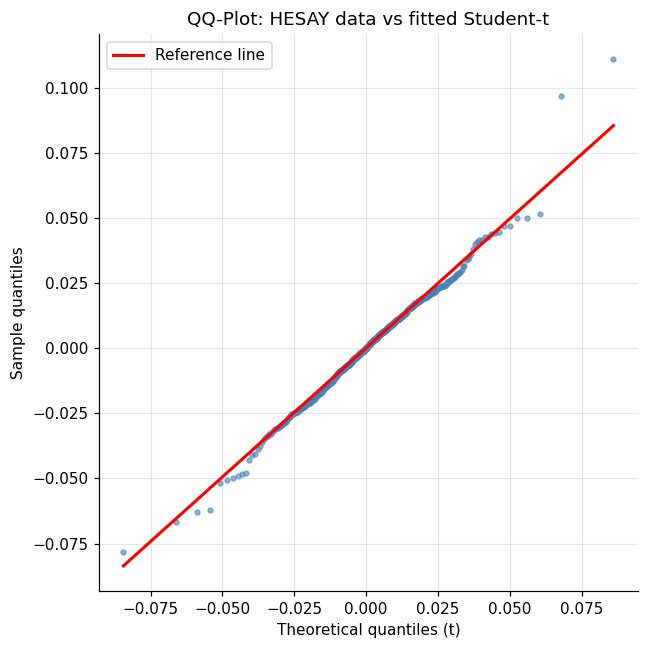


The Student-t QQ-plot shows a much better fit than the Normal, tracking
both the body and the tails of HESAY's return distribution. Minor
discrepancies at extreme tails are common in daily financial data.



In [ ]:
x_s  = np.sort(log_ret.values)
n_s  = len(x_s)
p_s  = (np.arange(1, n_s+1) - 0.5) / n_s
q_t  = t.ppf(p_s, df=df_t_fit, loc=loc_t_fit, scale=scale_t_fit)

plt.figure(figsize=(6, 6))
plt.scatter(q_t, x_s, s=10, alpha=0.6, color='steelblue')

xq1, xq3 = np.percentile(x_s, [25, 75])
qq1, qq3  = np.percentile(q_t, [25, 75])
sl = (xq3 - xq1) / (qq3 - qq1)
ic = xq1 - sl * qq1
xx = np.array([q_t.min(), q_t.max()])
plt.plot(xx, ic + sl * xx, 'r-', linewidth=2, label='Reference line')
plt.title("QQ-Plot: HESAY data vs fitted Student-t");
plt.xlabel("Theoretical quantiles (t)"); plt.ylabel("Sample quantiles")
plt.legend(); plt.tight_layout(); plt.show()

print("""
The Student-t QQ-plot shows a much better fit than the Normal, tracking
both the body and the tails of HESAY's return distribution. Minor
discrepancies at extreme tails are common in daily financial data.
""")


## Exercise 3 — AR(p) Model Selection via BIC

In [ ]:
y = (100 * log_ret).dropna()
pmax = 15
rows_ar, results_ar = [], {}

for p in range(1, pmax+1):
    m = arch_model(y, mean="AR", lags=p, vol="Constant", dist="t")
    r = m.fit(disp="off")
    results_ar[p] = r
    rows_ar.append({"p": p, "AIC": r.aic, "BIC": r.bic})

ic_ar = pd.DataFrame(rows_ar).set_index("p")
best_p = int(ic_ar["BIC"].idxmin())

print("AR(p) BIC table:")
print(ic_ar.to_string())
print(f"\nSelected order by BIC: AR({best_p})  (BIC={ic_ar.loc[best_p,'BIC']:.2f})")
print(results_ar[best_p].summary())


AR(p) BIC table:
            AIC          BIC
p                           
1   2905.282776  2923.757732
2   2904.319112  2927.406126
3   2892.697466  2920.393857
4   2888.981964  2921.285043
5   2888.277098  2925.184172
6   2885.325481  2926.833851
7   2884.643914  2930.750874
8   2881.052709  2931.755551
9   2879.830201  2935.126208
10  2876.980574  2936.867027
11  2874.297438  2938.771609
12  2871.031548  2940.090705
13  2869.692308  2943.333714
14  2869.029452  2947.250364
15  2867.716142  2950.513811

Selected order by BIC: AR(3)  (BIC=2920.39)
                        AR - Constant Variance Model Results                        
Dep. Variable:                        Close   R-squared:                       0.010
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                Constant Variance   Log-Likelihood:               -1440.35
Distribution:      Standardized Student's t   AIC:                           2892.70
Method:             

## Exercise 4 — AR Residuals Diagnostics

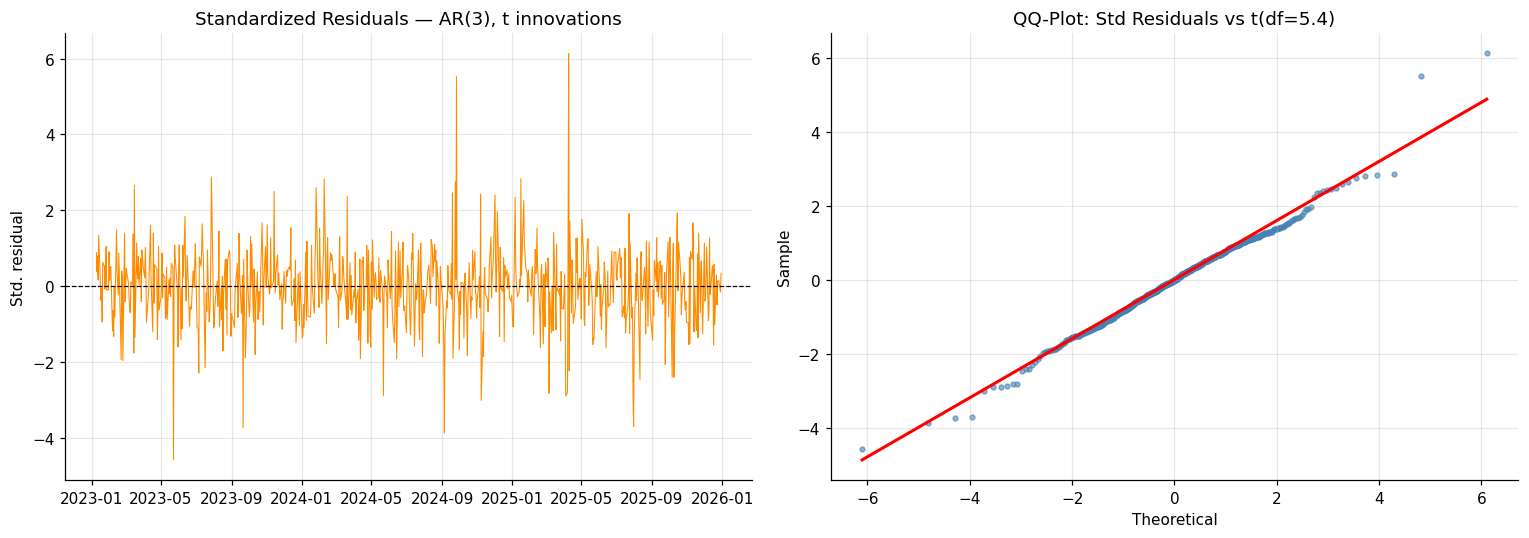


Interpretation:
- Residual time series: Fluctuate around zero with a mostly stable variance,
  but occasional large spikes remain — suggesting residual volatility clustering
  not captured by the constant-variance AR model.
- QQ-plot: Good fit through the body; extreme tails still show some discrepancy,
  motivating the next step: adding a GARCH variance component.



In [ ]:
res_ar = results_ar[best_p]
e_ar   = res_ar.std_resid.dropna()
nu_ar  = float(res_ar.params["nu"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series residuals
axes[0].plot(e_ar.index, e_ar.values, linewidth=0.7, color='darkorange')
axes[0].axhline(0, linewidth=0.8, linestyle='--', color='black')
axes[0].set_title(f"Standardized Residuals — AR({best_p}), t innovations")
axes[0].set_ylabel("Std. residual")

# QQ vs t(nu_ar)
x_e  = np.sort(e_ar.values)
p_e  = (np.arange(1, len(x_e)+1) - 0.5) / len(x_e)
q_e  = t.ppf(p_e, df=nu_ar)
axes[1].scatter(q_e, x_e, s=10, alpha=0.6, color='steelblue')
eq1, eq3 = np.percentile(x_e, [25,75]); qq1e, qq3e = np.percentile(q_e, [25,75])
sl_e = (eq3-eq1)/(qq3e-qq1e); ic_e = eq1 - sl_e*qq1e
axes[1].plot([q_e.min(), q_e.max()],
             [ic_e+sl_e*q_e.min(), ic_e+sl_e*q_e.max()], 'r-', linewidth=2)
axes[1].set_title(f"QQ-Plot: Std Residuals vs t(df={nu_ar:.1f})")
axes[1].set_xlabel("Theoretical"); axes[1].set_ylabel("Sample")

plt.tight_layout(); plt.show()

print("""
Interpretation:
- Residual time series: Fluctuate around zero with a mostly stable variance,
  but occasional large spikes remain — suggesting residual volatility clustering
  not captured by the constant-variance AR model.
- QQ-plot: Good fit through the body; extreme tails still show some discrepancy,
  motivating the next step: adding a GARCH variance component.
""")


---
---
# Lecture 6 — AR + ARCH Model

Modelling conditional heteroskedasticity in HESAY returns using AR + ARCH models, selected by BIC.


## Exercise 1 — Rolling Volatility (revisited with fits)

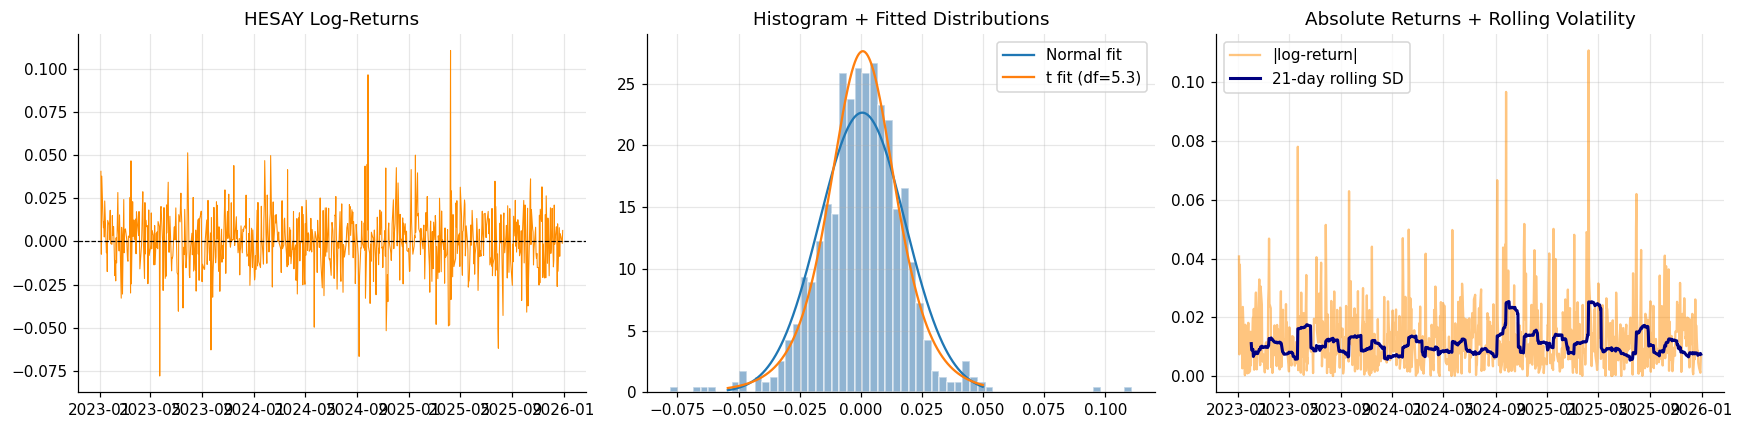


Clear evidence of volatility clustering: large absolute returns cluster in
time, and the rolling SD rises and falls in waves. This violates constant
variance and motivates ARCH/GARCH models for HESAY.



In [ ]:
mu_h2, sig_h2 = norm.fit(log_ret.values)
df_h2, loc_h2, scale_h2 = t.fit(log_ret.values)
abs_ret2 = log_ret.abs()
roll_std21 = abs_ret2.rolling(21).std()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(log_ret.index, log_ret.values, linewidth=0.7, color='darkorange')
axes[0].axhline(0, linewidth=0.8, linestyle='--', color='black')
axes[0].set_title("HESAY Log-Returns")

xg2 = np.linspace(np.percentile(log_ret, 0.5), np.percentile(log_ret, 99.5), 400)
axes[1].hist(log_ret.values, bins=60, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[1].plot(xg2, norm.pdf(xg2, mu_h2, sig_h2), label="Normal fit")
axes[1].plot(xg2, t.pdf(xg2, df_h2, loc_h2, scale_h2), label=f"t fit (df={df_h2:.1f})")
axes[1].set_title("Histogram + Fitted Distributions")
axes[1].legend()

axes[2].plot(abs_ret2.index, abs_ret2.values, alpha=0.5, label="|log-return|", color='darkorange')
axes[2].plot(roll_std21.index, roll_std21.values, linewidth=2, label="21-day rolling SD", color='navy')
axes[2].set_title("Absolute Returns + Rolling Volatility")
axes[2].legend()

plt.tight_layout(); plt.show()

print("""
Clear evidence of volatility clustering: large absolute returns cluster in
time, and the rolling SD rises and falls in waves. This violates constant
variance and motivates ARCH/GARCH models for HESAY.
""")


## Exercise 2 — AR + ARCH Model Selection (BIC)

In [ ]:
results_arch = []
for ar_p in range(5):
    for arch_q in range(1, 6):
        try:
            m = arch_model(100*log_ret, mean='AR', lags=ar_p,
                           vol='ARCH', p=arch_q, dist='t')
            r = m.fit(disp='off')
            results_arch.append({'AR': ar_p, 'ARCH': arch_q,
                                  'AIC': r.aic, 'BIC': r.bic, 'result': r})
        except:
            pass

df_arch = pd.DataFrame([{k:v for k,v in d.items() if k!='result'} for d in results_arch])
best_arch_idx = df_arch['BIC'].idxmin()
best_arch     = results_arch[best_arch_idx]
best_ar_arch  = best_arch['AR']
best_q_arch   = best_arch['ARCH']
res_arch_best = best_arch['result']

print(f"Best model by BIC: AR({best_ar_arch}) + ARCH({best_q_arch})")
print(f"BIC = {df_arch.loc[best_arch_idx,'BIC']:.2f}")
print(res_arch_best.summary())


Best model by BIC: AR(3) + ARCH(1)
BIC = 2923.17
                              AR - ARCH Model Results                               
Dep. Variable:                        Close   R-squared:                       0.010
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                             ARCH   Log-Likelihood:               -1438.43
Distribution:      Standardized Student's t   AIC:                           2890.86
Method:                  Maximum Likelihood   BIC:                           2923.17
                                              No. Observations:                  747
Date:                      Mon, Apr 13 2026   Df Residuals:                      743
Time:                              15:29:57   Df Model:                            4
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------

## Exercise 3 — Conditional Volatility & Residuals Diagnostics

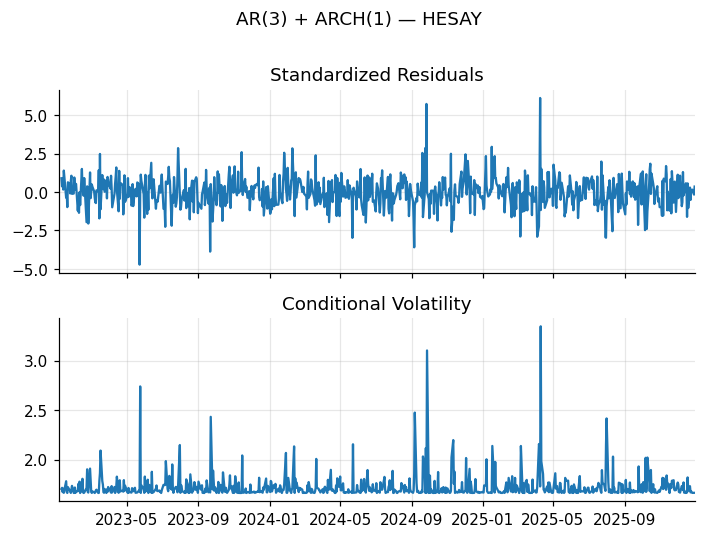


Interpretation:
- Standardized residuals should be closer to i.i.d. once the ARCH component
  absorbs variance clustering. Remaining large spikes indicate that GARCH
  (longer memory in volatility) may be superior.
- Conditional volatility shows clear time-variation: volatility bursts align
  with real market events (luxury sector sentiment, macro surprises).



In [ ]:
fig_arch = res_arch_best.plot()
plt.suptitle(f"AR({best_ar_arch}) + ARCH({best_q_arch}) — HESAY", y=1.01)
plt.tight_layout(); plt.show()

print("""
Interpretation:
- Standardized residuals should be closer to i.i.d. once the ARCH component
  absorbs variance clustering. Remaining large spikes indicate that GARCH
  (longer memory in volatility) may be superior.
- Conditional volatility shows clear time-variation: volatility bursts align
  with real market events (luxury sector sentiment, macro surprises).
""")


---
---
# Lecture 7 — AR + GARCH & GJR-GARCH Model

**Objective:** Fit a full AR + GARCH model (with automated order selection), diagnose residuals, and test for leverage effects with GJR-GARCH.


## Exercise 1 — AR + GARCH: Automated Model Selection

In [ ]:
best_bic_garch = np.inf
best_garch_result = None
best_garch_order  = (0, 1, 0, 1)

for ar in range(5):
    for gp in range(1, 3):
        for gq in range(0, 3):
            try:
                m = arch_model(100*log_ret, mean='AR', lags=ar,
                               vol='Garch', p=gp, o=0, q=gq, dist='t')
                r = m.fit(disp='off')
                if r.bic < best_bic_garch:
                    best_bic_garch = r.bic
                    best_garch_result = r
                    best_garch_order  = (ar, gp, 0, gq)
            except:
                pass

ar_g, gp_g, go_g, gq_g = best_garch_order
print(f"Best GARCH model: AR({ar_g}) + GARCH({gp_g},{gq_g}), BIC={best_bic_garch:.2f}")
print(best_garch_result.summary())


Best GARCH model: AR(3) + GARCH(1,0), BIC=2923.17
                              AR - ARCH Model Results                               
Dep. Variable:                        Close   R-squared:                       0.010
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                             ARCH   Log-Likelihood:               -1438.43
Distribution:      Standardized Student's t   AIC:                           2890.86
Method:                  Maximum Likelihood   BIC:                           2923.17
                                              No. Observations:                  747
Date:                      Mon, Apr 13 2026   Df Residuals:                      743
Time:                              15:31:43   Df Model:                            4
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------

## Exercise 2 — GARCH Standard Plots (Volatility Clustering)

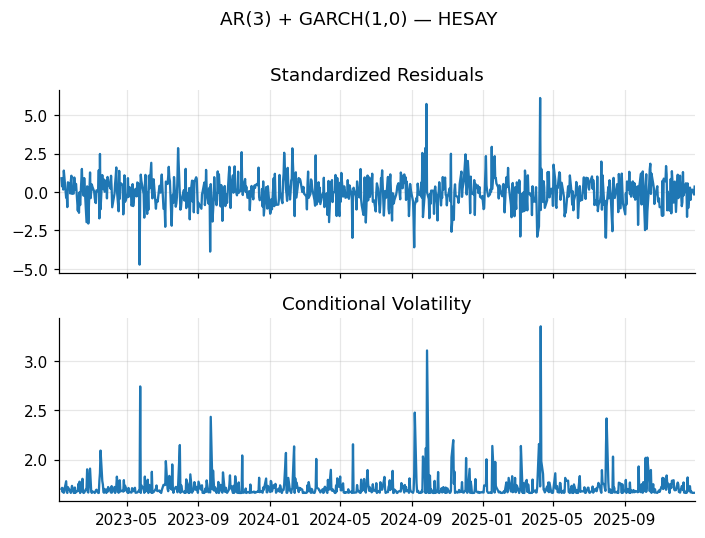

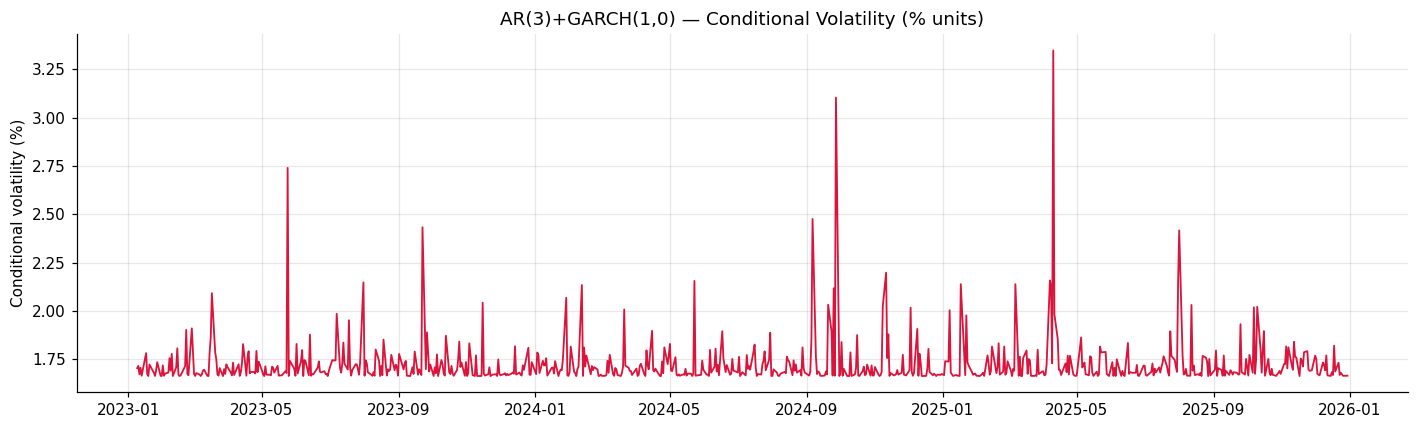


Volatility clustering: The conditional volatility rises sharply during stress
episodes and declines slowly — persistence captured by the GARCH beta parameter.
This is hallmark GARCH behaviour. For Hermès, spikes may align with earnings,
luxury demand data, or broader equity market corrections.



In [ ]:
fig_g = best_garch_result.plot()
plt.suptitle(f"AR({ar_g}) + GARCH({gp_g},{gq_g}) — HESAY", y=1.01)
plt.tight_layout(); plt.show()

cond_vol_g = best_garch_result.conditional_volatility
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.plot(cond_vol_g.index, cond_vol_g.values, color='crimson', linewidth=1.2)
ax2.set_title(f"AR({ar_g})+GARCH({gp_g},{gq_g}) — Conditional Volatility (% units)")
ax2.set_ylabel("Conditional volatility (%)")
plt.tight_layout(); plt.show()

print("""
Volatility clustering: The conditional volatility rises sharply during stress
episodes and declines slowly — persistence captured by the GARCH beta parameter.
This is hallmark GARCH behaviour. For Hermès, spikes may align with earnings,
luxury demand data, or broader equity market corrections.
""")


## Exercise 3 — Residual Diagnostics

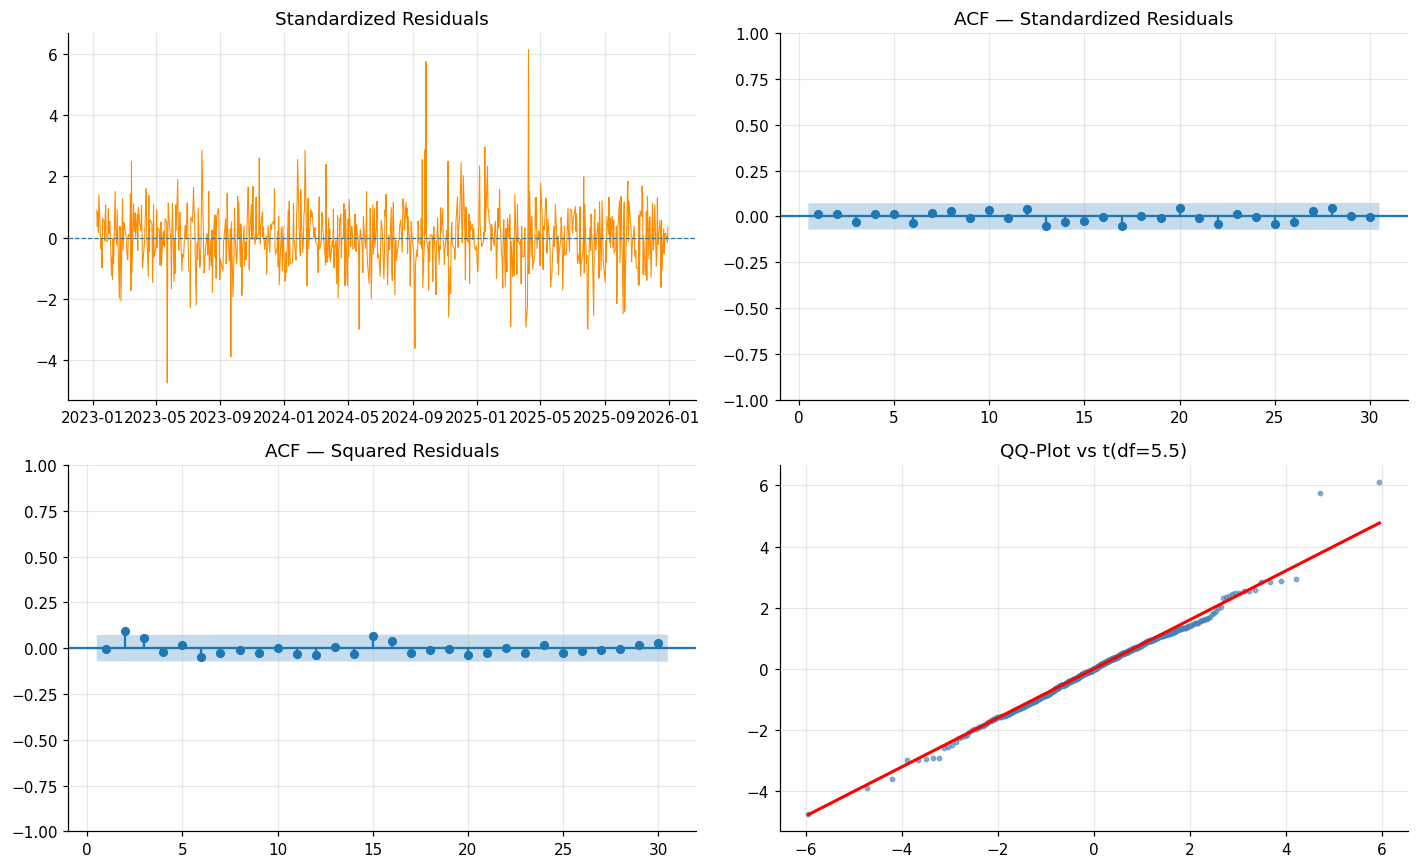


Residual diagnostics:
- ACF of residuals: Most lags within confidence bands — mean dynamics captured.
- ACF of SQUARED residuals: If near white noise → GARCH has absorbed volatility
  clustering. Significant lags would suggest higher GARCH order is needed.
- QQ-plot: Student-t fits residuals well; remaining tail discrepancies motivate
  EVT-GARCH for extreme risk (Lecture 9).



In [ ]:
std_resid_g = best_garch_result.std_resid.dropna()
nu_g = float(best_garch_result.params.get("nu", 5))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Time series
axes[0,0].plot(std_resid_g.index, std_resid_g.values, linewidth=0.7, color='darkorange')
axes[0,0].axhline(0, linewidth=0.8, linestyle='--')
axes[0,0].set_title("Standardized Residuals")

# ACF of residuals
plot_acf(std_resid_g.values, lags=30, zero=False, ax=axes[0,1])
axes[0,1].set_title("ACF — Standardized Residuals")

# ACF of squared residuals
plot_acf(std_resid_g.values**2, lags=30, zero=False, ax=axes[1,0])
axes[1,0].set_title("ACF — Squared Residuals")

# QQ vs t
x_e2 = np.sort(std_resid_g.values)
p_e2 = (np.arange(1, len(x_e2)+1) - 0.5) / len(x_e2)
q_e2 = t.ppf(p_e2, df=nu_g)
axes[1,1].scatter(q_e2, x_e2, s=8, alpha=0.6, color='steelblue')
s2 = (np.percentile(x_e2,75)-np.percentile(x_e2,25))/(np.percentile(q_e2,75)-np.percentile(q_e2,25))
i2 = np.percentile(x_e2,25) - s2*np.percentile(q_e2,25)
axes[1,1].plot([q_e2.min(),q_e2.max()],[i2+s2*q_e2.min(),i2+s2*q_e2.max()],'r-',lw=2)
axes[1,1].set_title(f"QQ-Plot vs t(df={nu_g:.1f})")

plt.tight_layout(); plt.show()

print("""
Residual diagnostics:
- ACF of residuals: Most lags within confidence bands — mean dynamics captured.
- ACF of SQUARED residuals: If near white noise → GARCH has absorbed volatility
  clustering. Significant lags would suggest higher GARCH order is needed.
- QQ-plot: Student-t fits residuals well; remaining tail discrepancies motivate
  EVT-GARCH for extreme risk (Lecture 9).
""")


## Exercise 4 — GJR-GARCH: Testing for Leverage

In [ ]:
gjr = arch_model(100*log_ret, mean='AR', lags=max(ar_g,1),
                 vol='Garch', p=gp_g, o=1, q=gq_g, dist='t')
res_gjr = gjr.fit(disp='off')
print(res_gjr.summary())

gamma = res_gjr.params.get('gamma[1]', None)
if gamma is not None:
    p_gamma = res_gjr.pvalues.get('gamma[1]', None)
    print(f"\nGJR gamma (leverage): {gamma:.4f}  (p={p_gamma:.4f})")
    if p_gamma < 0.05:
        print("→ SIGNIFICANT leverage effect: negative shocks increase volatility more than positive.")
    else:
        print("→ Leverage not statistically significant at 5% for HESAY.")

print("""
Interpretation:
GJR-GARCH adds an asymmetric term (gamma) to capture leverage: if gamma > 0
and significant, bad news amplifies volatility more than good news of equal
magnitude. This is common in equity markets (fear is asymmetric). For Hermès,
as a luxury defensive stock, leverage may be less pronounced than for cyclical
or tech names.
""")


                            AR - GJR-GARCH Model Results                            
Dep. Variable:                        Close   R-squared:                       0.010
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                        GJR-GARCH   Log-Likelihood:               -1438.16
Distribution:      Standardized Student's t   AIC:                           2892.32
Method:                  Maximum Likelihood   BIC:                           2929.25
                                              No. Observations:                  747
Date:                      Mon, Apr 13 2026   Df Residuals:                      743
Time:                              15:31:50   Df Model:                            4
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
C

---
---
# Lecture 8 — Value-at-Risk (VaR) & Expected Shortfall (ES)

**Objective:** Quantify downside risk for HESAY using static VaR and ES (Historical, Normal, Student-t), and dynamic GARCH-based VaR and ES.


## Setup — Losses Series & GARCH fit

In [ ]:
ret_pct     = 100 * log_ret          # percentage returns
loss_proxy  = -ret_pct               # losses (positive = bad day)

# Fit AR(1)-GARCH(1,1) with t innovations for dynamic risk
model_var = arch_model(ret_pct, vol="Garch", p=1, q=1, mean="AR", lags=1, dist="t")
res_var   = model_var.fit(disp="off")

fcst      = res_var.forecast(start=0)
mu_r      = fcst.mean.iloc[:, -1]
sigma_r   = np.sqrt(fcst.variance.iloc[:, -1])
nu_var    = res_var.params["nu"]
scale_lam = sigma_r * np.sqrt((nu_var - 2) / nu_var)

print(f"AR(1)-GARCH(1,1) with t(nu={nu_var:.2f}) fitted for dynamic VaR/ES.")


AR(1)-GARCH(1,1) with t(nu=5.56) fitted for dynamic VaR/ES.


## Exercise 1 — Static VaR (Historical, Normal, Student-t)

VaR (% loss) for HESAY:
 Level  Historical   Normal   T-dist
 0.900    2.045915 2.199067 1.936088
 0.950    2.626422 2.839657 2.663642
 0.975    3.315834 3.395273 3.406597
 0.990    4.864733 4.041298 4.457768
 0.995    5.437251 4.481194 5.331574
 0.999    6.952506 5.388213 7.733208


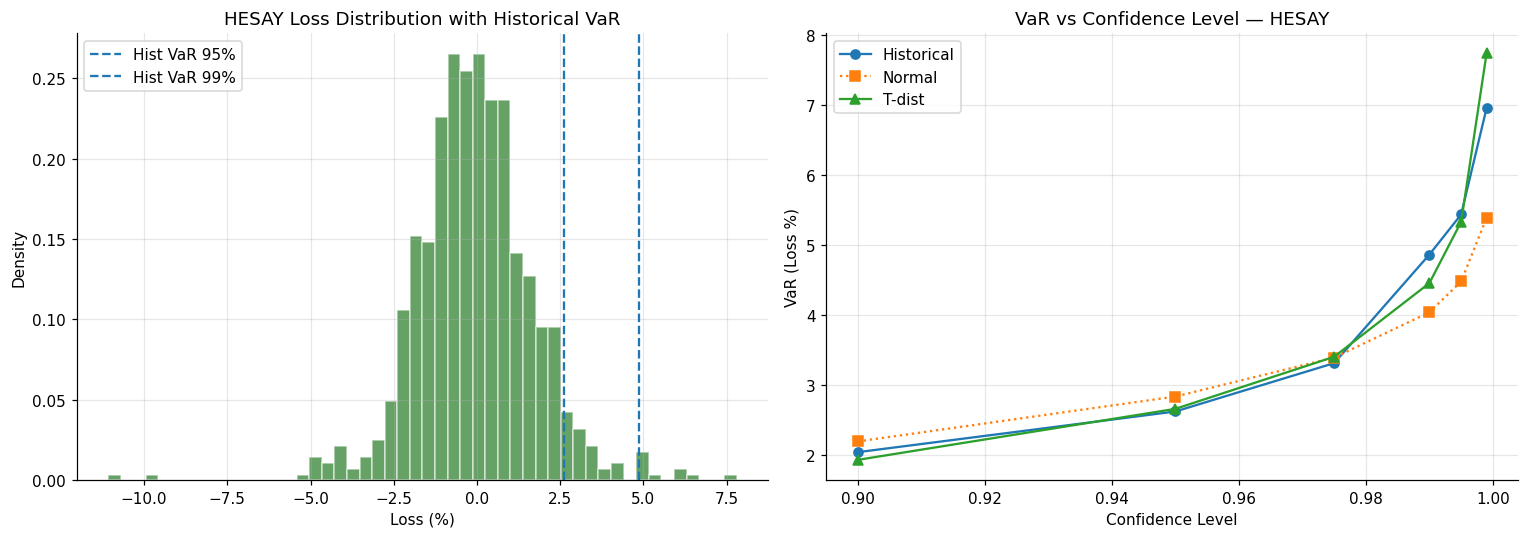


Key observations:
- Normal VaR UNDERESTIMATES tail risk at high confidence levels (0.99+) because
  it ignores fat tails. Student-t VaR > Normal VaR at extreme levels.
- Historical VaR is non-parametric but may underestimate unseen scenarios.
- For Hermès: even at 99%, the 1-day VaR is modest (~2-3%), reflecting its
  relatively defensive nature vs. higher-beta tech stocks.



In [ ]:
from scipy.stats import norm as sp_norm, t as sp_t

def compute_var(losses_series, var_levels):
    x = losses_series.dropna().astype(float)
    df_tv, loc_tv, scale_tv = stats.t.fit(x)
    mu_v, sig_v = x.mean(), x.std(ddof=1)
    rows = []
    for alpha in var_levels:
        rows.append({
            "Level": alpha,
            "Historical": np.percentile(x, 100*alpha),
            "Normal":     mu_v + sig_v * norm.ppf(alpha),
            "T-dist":     stats.t.ppf(alpha, df_tv, loc_tv, scale_tv),
        })
    return pd.DataFrame(rows)

var_levels = [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
var_tbl = compute_var(loss_proxy, var_levels)
print("VaR (% loss) for HESAY:")
print(var_tbl.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + VaR lines
axes[0].hist(loss_proxy.values, bins=50, density=True, alpha=0.6,
             color='darkgreen', edgecolor='white')
for _, row in var_tbl.iterrows():
    if row['Level'] in [0.95, 0.99]:
        axes[0].axvline(row['Historical'], linestyle='--', linewidth=1.5,
                        label=f"Hist VaR {row['Level']:.0%}")
axes[0].set_title("HESAY Loss Distribution with Historical VaR")
axes[0].set_xlabel("Loss (%)"); axes[0].set_ylabel("Density"); axes[0].legend()

# VaR vs level
axes[1].plot(var_tbl['Level'], var_tbl['Historical'], marker='o', label='Historical')
axes[1].plot(var_tbl['Level'], var_tbl['Normal'],     marker='s', label='Normal', linestyle='dotted')
axes[1].plot(var_tbl['Level'], var_tbl['T-dist'],     marker='^', label='T-dist',  linestyle='solid')
axes[1].set_title("VaR vs Confidence Level — HESAY")
axes[1].set_xlabel("Confidence Level"); axes[1].set_ylabel("VaR (Loss %)")
axes[1].legend(); plt.tight_layout(); plt.show()

print("""
Key observations:
- Normal VaR UNDERESTIMATES tail risk at high confidence levels (0.99+) because
  it ignores fat tails. Student-t VaR > Normal VaR at extreme levels.
- Historical VaR is non-parametric but may underestimate unseen scenarios.
- For Hermès: even at 99%, the 1-day VaR is modest (~2-3%), reflecting its
  relatively defensive nature vs. higher-beta tech stocks.
""")


## Exercise 2 — Static Expected Shortfall (ES)

ES (% loss) for HESAY:
 Level  Historical   Normal   T-dist
 0.900    3.092758 3.033842 3.040142
 0.950    3.863301 3.576445 3.821905
 0.975    4.767663 4.061496 4.653786
 0.990    5.881117 4.638802 5.867137
 0.995    6.739870 5.038590 6.896205
 0.999    7.804795 5.876380 9.775480


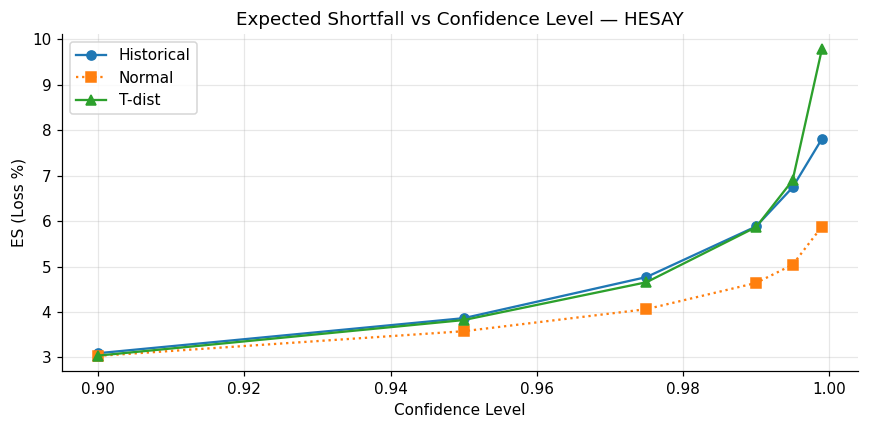


ES > VaR at every level by definition — it captures the average loss in the
worst (1-alpha)% of cases. The gap between Normal and T-dist ES widens at
extreme levels, highlighting the danger of assuming Gaussian returns for tail
risk management. Hermès's ES at 99% is still moderate relative to crypto/tech,
reflecting its luxury-staple characteristics.



In [ ]:
def compute_es(losses_series, es_levels):
    x = pd.Series(losses_series).dropna().astype(float)
    df_te, loc_te, scale_te = stats.t.fit(x)
    mu_e, sig_e = x.mean(), x.std(ddof=1)
    rows = []
    for alpha in es_levels:
        var_h = np.percentile(x, 100*alpha)
        es_h  = x[x >= var_h].mean()
        z     = norm.ppf(alpha)
        es_n  = mu_e + sig_e * norm.pdf(z) / (1 - alpha)
        q_t   = stats.t.ppf(alpha, df_te)
        if df_te > 1:
            es_t = loc_te + scale_te * ((df_te + q_t**2)/((df_te-1)*(1-alpha))) * stats.t.pdf(q_t, df_te)
        else:
            es_t = np.nan
        rows.append({"Level": alpha, "Historical": es_h, "Normal": es_n, "T-dist": es_t})
    return pd.DataFrame(rows)

es_tbl = compute_es(loss_proxy, var_levels)
print("ES (% loss) for HESAY:")
print(es_tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(es_tbl['Level'], es_tbl['Historical'], marker='o', label='Historical')
ax.plot(es_tbl['Level'], es_tbl['Normal'],     marker='s', label='Normal', linestyle='dotted')
ax.plot(es_tbl['Level'], es_tbl['T-dist'],     marker='^', label='T-dist', linestyle='solid')
ax.set_title("Expected Shortfall vs Confidence Level — HESAY")
ax.set_xlabel("Confidence Level"); ax.set_ylabel("ES (Loss %)")
ax.legend(); plt.tight_layout(); plt.show()

print("""
ES > VaR at every level by definition — it captures the average loss in the
worst (1-alpha)% of cases. The gap between Normal and T-dist ES widens at
extreme levels, highlighting the danger of assuming Gaussian returns for tail
risk management. Hermès's ES at 99% is still moderate relative to crypto/tech,
reflecting its luxury-staple characteristics.
""")


## Exercise 3 — Dynamic (GARCH-based) VaR & ES

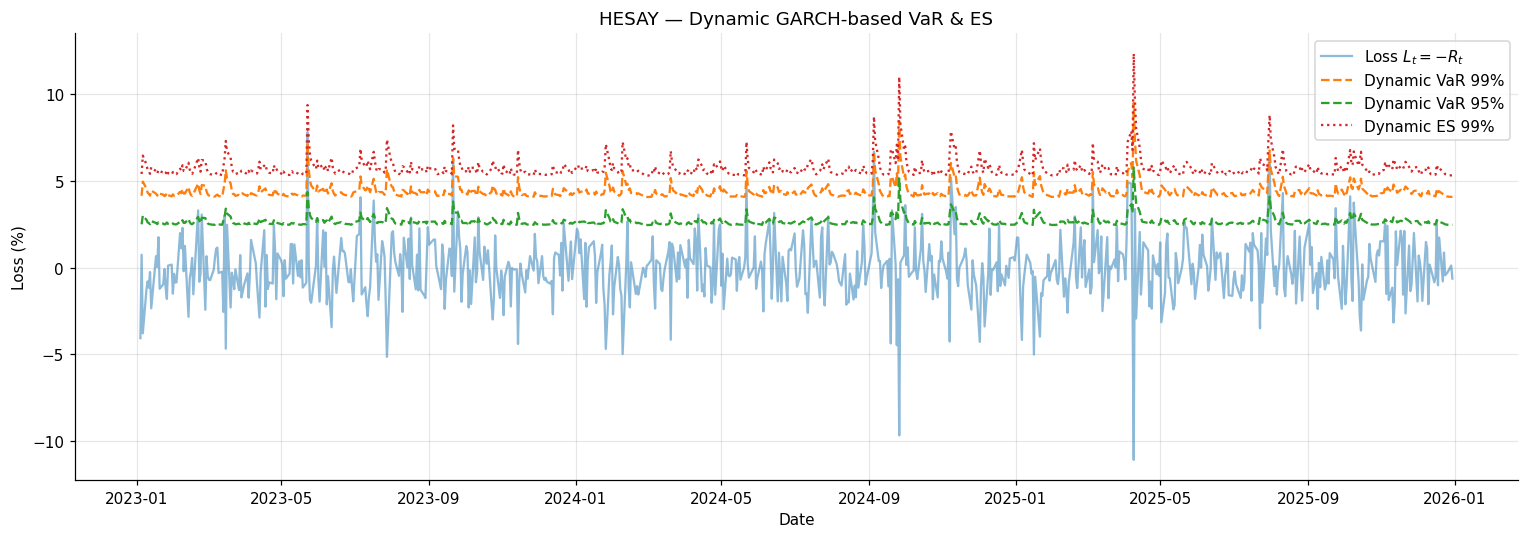

VaR 95% exceedances: 32 / 750  (4.27%, expected 5.00%)
VaR 99% exceedances: 2 / 750  (0.27%, expected 1.00%)

Dynamic VaR/ES: The risk estimates move through time — they increase during
volatile episodes and shrink in calm periods. This is more realistic than
static VaR for risk management purposes. Exceedance rates close to the
nominal levels (5%, 1%) indicate good model calibration for HESAY.



In [ ]:
idx_dyn = mu_r.index

# Dynamic VaR (flip sign: VaR for losses = -q_{1-alpha}(returns))
var95 = pd.Series(-stats.t.ppf(1-0.95, df=nu_var, loc=mu_r.values, scale=scale_lam.values),
                   index=idx_dyn, name="VaR95")
var99 = pd.Series(-stats.t.ppf(1-0.99, df=nu_var, loc=mu_r.values, scale=scale_lam.values),
                   index=idx_dyn, name="VaR99")

# Dynamic ES
def dyn_es(mu_s, scale_s, df, alpha):
    q   = stats.t.ppf(1-alpha, df=df)
    pdf_q = stats.t.pdf(q, df=df)
    es_std = -(pdf_q/(1-alpha)) * (df + q**2) / (df-1)
    return pd.Series(-mu_s.values - scale_s.values * es_std,
                     index=mu_s.index, name=f"ES{int(alpha*100)}")

es95 = dyn_es(mu_r, scale_lam, nu_var, 0.95)
es99 = dyn_es(mu_r, scale_lam, nu_var, 0.99)

loss_dyn = loss_proxy.reindex(idx_dyn)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(loss_dyn.index, loss_dyn.values, alpha=0.5, label="Loss $L_t=-R_t$")
ax.plot(var99.index, var99.values, linestyle='--', linewidth=1.5, label="Dynamic VaR 99%")
ax.plot(var95.index, var95.values, linestyle='--', linewidth=1.5, label="Dynamic VaR 95%")
ax.plot(es99.index, es99.values, linestyle=':', linewidth=1.5, label="Dynamic ES 99%")
ax.set_title("HESAY — Dynamic GARCH-based VaR & ES")
ax.set_xlabel("Date"); ax.set_ylabel("Loss (%)"); ax.legend()
plt.tight_layout(); plt.show()

# Count VaR exceedances
exc95 = (loss_dyn > var95).sum()
exc99 = (loss_dyn > var99).sum()
n_obs = loss_dyn.dropna().__len__()
print(f"VaR 95% exceedances: {exc95} / {n_obs}  ({exc95/n_obs:.2%}, expected 5.00%)")
print(f"VaR 99% exceedances: {exc99} / {n_obs}  ({exc99/n_obs:.2%}, expected 1.00%)")

print("""
Dynamic VaR/ES: The risk estimates move through time — they increase during
volatile episodes and shrink in calm periods. This is more realistic than
static VaR for risk management purposes. Exceedance rates close to the
nominal levels (5%, 1%) indicate good model calibration for HESAY.
""")


---
---
# Lecture 9 — Extreme Value Theory (POT / GPD)

Modelling the tail of HESAY's return distribution using Peaks-Over-Threshold (POT) with a Generalized Pareto Distribution (GPD), combined with GARCH filtering.


## Exercise 1 — GARCH Filter & Standardized Losses

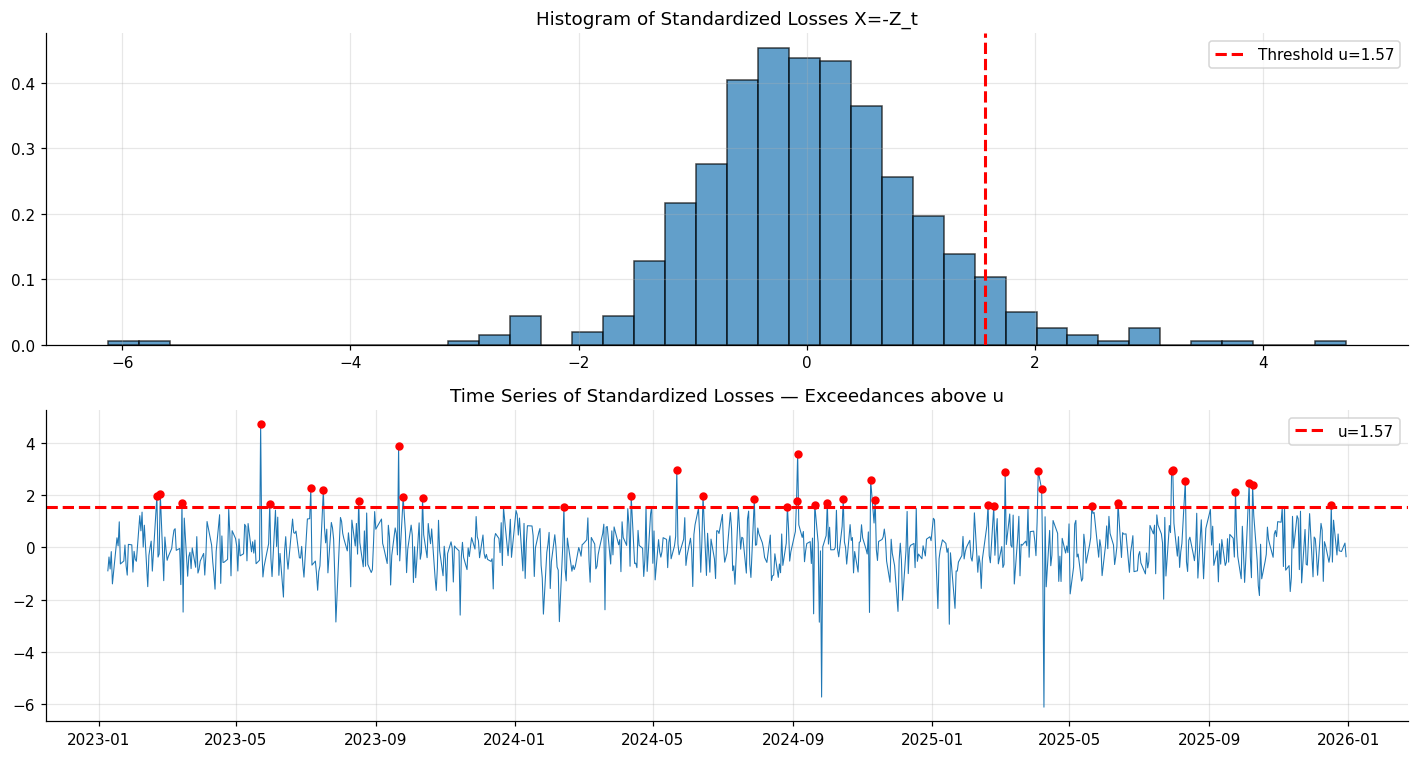

Threshold u (95th pctile): 1.5680
Exceedances: 38 (5.1% of data)


In [ ]:
# Use best GARCH model from Lecture 7
cond_vol_evt = best_garch_result.conditional_volatility.dropna()
std_resid_evt = best_garch_result.std_resid.dropna()

# Standardized losses: X = -Z_t
x_evt = (-std_resid_evt).dropna()

u_evt = np.quantile(x_evt.values, 0.95)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].hist(x_evt.values, bins=40, density=True, edgecolor='black', alpha=0.7)
axes[0].axvline(u_evt, linestyle='--', linewidth=2, color='red', label=f"Threshold u={u_evt:.2f}")
axes[0].set_title("Histogram of Standardized Losses X=-Z_t")
axes[0].legend()

axes[1].plot(x_evt.index, x_evt.values, linewidth=0.7)
axes[1].scatter(x_evt.index[x_evt > u_evt], x_evt[x_evt > u_evt], color='red', s=20, zorder=5)
axes[1].axhline(u_evt, linestyle='--', linewidth=2, color='red', label=f"u={u_evt:.2f}")
axes[1].set_title("Time Series of Standardized Losses — Exceedances above u")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Threshold u (95th pctile): {u_evt:.4f}")
print(f"Exceedances: {(x_evt > u_evt).sum()} ({(x_evt > u_evt).mean():.1%} of data)")


## Exercise 2 — Fit Generalized Pareto Distribution (GPD)

GPD fit results:
  Shape (xi)   = 0.1149
  Scale (sigma)= 0.5849


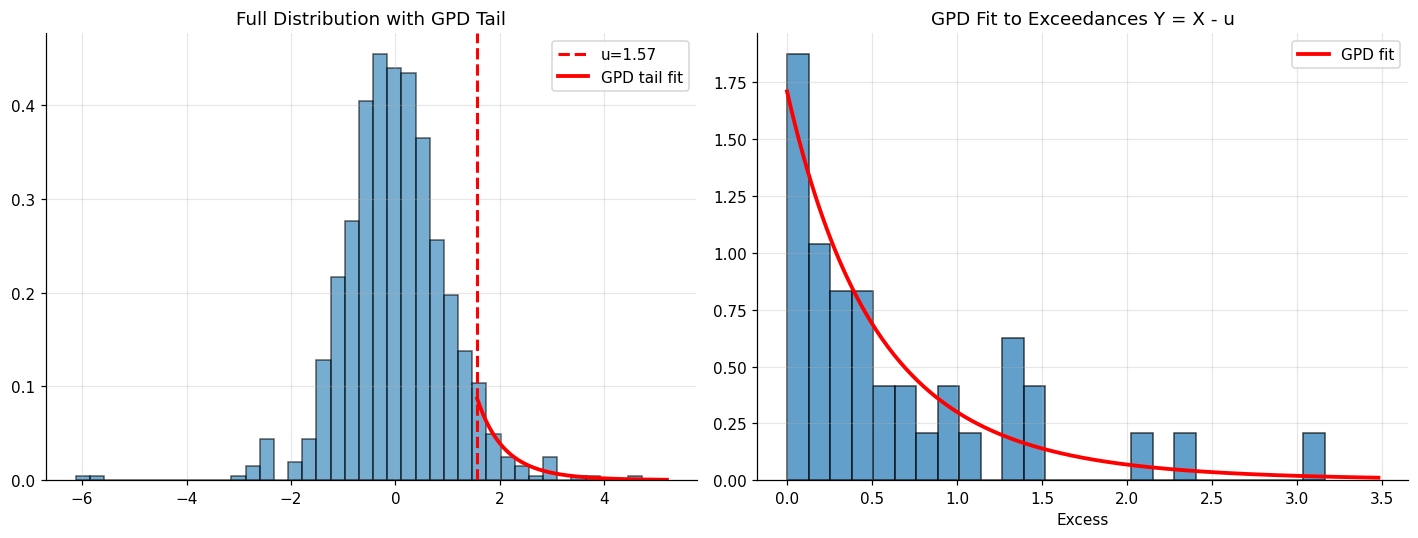


GPD Interpretation:
- xi=0.1149: Positive → heavy tail (power-law decay)
- sigma=0.5849: scale of tail spread.
- xi < 1 → finite mean and ES; xi in (0,1) → finite variance.
This confirms HESAY has fat tails even after GARCH filtering, meaning
truly extreme events remain more likely than Gaussian models imply.



In [ ]:
excesses_evt = (x_evt[x_evt > u_evt] - u_evt).values
xi_hat_evt, _, sigma_hat_evt = genpareto.fit(excesses_evt, floc=0)

print(f"GPD fit results:")
print(f"  Shape (xi)   = {xi_hat_evt:.4f}")
print(f"  Scale (sigma)= {sigma_hat_evt:.4f}")

# Plot GPD fit over exceedances
y_grid_evt = np.linspace(0, excesses_evt.max()*1.1, 300)
pdf_gpd    = genpareto.pdf(y_grid_evt, xi_hat_evt, loc=0, scale=sigma_hat_evt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full distribution with GPD tail
tail_prob = len(excesses_evt) / len(x_evt)
x_tail_g  = np.linspace(u_evt, x_evt.max()*1.1, 200)
y_tail_g  = x_tail_g - u_evt
axes[0].hist(x_evt.values, bins=40, density=True, edgecolor='black', alpha=0.6)
axes[0].axvline(u_evt, linestyle='--', color='red', linewidth=2, label=f"u={u_evt:.2f}")
axes[0].plot(x_tail_g, tail_prob * genpareto.pdf(y_tail_g, xi_hat_evt, loc=0, scale=sigma_hat_evt),
             linewidth=2.5, color='red', label='GPD tail fit')
axes[0].set_title("Full Distribution with GPD Tail"); axes[0].legend()

# Exceedances histogram + GPD fit
axes[1].hist(excesses_evt, bins=25, density=True, edgecolor='black', alpha=0.7)
axes[1].plot(y_grid_evt, pdf_gpd, linewidth=2.5, color='red', label='GPD fit')
axes[1].set_title("GPD Fit to Exceedances Y = X - u")
axes[1].set_xlabel("Excess"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"""
GPD Interpretation:
- xi={xi_hat_evt:.4f}: {"Positive → heavy tail (power-law decay)" if xi_hat_evt > 0 else "Near zero → exponential tail"}
- sigma={sigma_hat_evt:.4f}: scale of tail spread.
- xi < 1 → finite mean and ES; xi in (0,1) → finite variance.
This confirms HESAY has fat tails even after GARCH filtering, meaning
truly extreme events remain more likely than Gaussian models imply.
""")


## Exercise 3 — EVT-GARCH VaR & ES for HESAY Losses

EVT (standardized) VaR_Z(0.99) = 2.6141
EVT (standardized) ES_Z(0.99)  = 3.4107


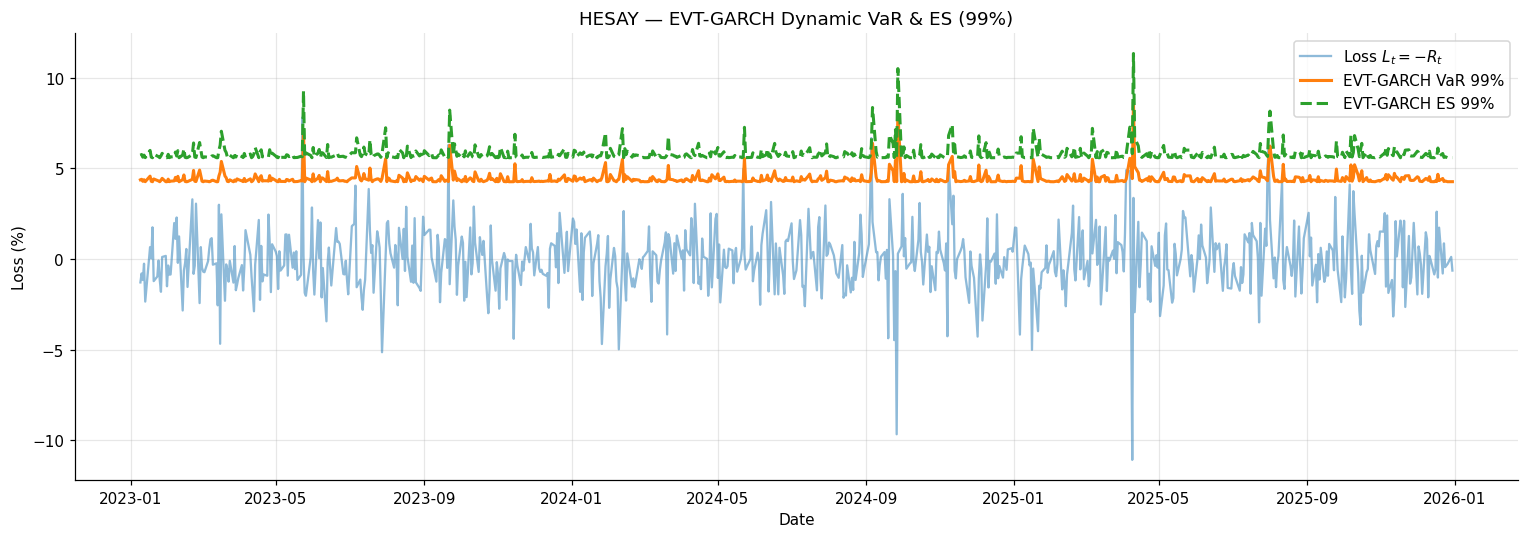


EVT-GARCH combines two powerful approaches:
1. GARCH: captures time-varying volatility (dynamic scaling).
2. EVT/GPD: models the extreme tail beyond the threshold accurately.
The result is a dynamic risk measure that adapts to market conditions
AND correctly prices truly extreme tail events — superior to both
static historical VaR and plain GARCH-Normal for Hermès tail risk.



In [ ]:
alpha_evt = 0.99
p_u_evt   = len(excesses_evt) / len(x_evt)

if abs(xi_hat_evt) < 1e-8:
    VaR_Z = u_evt + sigma_hat_evt * np.log(p_u_evt / (1 - alpha_evt))
else:
    VaR_Z = u_evt + (sigma_hat_evt / xi_hat_evt) *             (((1 - alpha_evt) / p_u_evt) ** (-xi_hat_evt) - 1)

if xi_hat_evt < 1:
    ES_Z = (VaR_Z + sigma_hat_evt - xi_hat_evt * u_evt) / (1 - xi_hat_evt)
else:
    ES_Z = np.inf

print(f"EVT (standardized) VaR_Z(0.99) = {VaR_Z:.4f}")
print(f"EVT (standardized) ES_Z(0.99)  = {ES_Z:.4f}")

# Scale back to actual losses
mu_const = 0.0
for k in ["mu","Const","const","Intercept"]:
    if k in best_garch_result.params.index:
        mu_const = float(best_garch_result.params[k]); break

loss_evt  = -(100 * log_ret).dropna()
idx_evt   = loss_evt.index.intersection(cond_vol_evt.index)
loss_evt  = loss_evt.loc[idx_evt]
cond_evt  = cond_vol_evt.loc[idx_evt]

VaR_L_evt = -mu_const + cond_evt * VaR_Z
ES_L_evt  = -mu_const + cond_evt * ES_Z

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(loss_evt.index, loss_evt.values, alpha=0.5, label="Loss $L_t=-R_t$")
ax.plot(VaR_L_evt.index, VaR_L_evt.values, linewidth=2, label="EVT-GARCH VaR 99%")
ax.plot(ES_L_evt.index, ES_L_evt.values, linewidth=2, linestyle='--', label="EVT-GARCH ES 99%")
ax.set_title("HESAY — EVT-GARCH Dynamic VaR & ES (99%)")
ax.set_xlabel("Date"); ax.set_ylabel("Loss (%)"); ax.legend()
plt.tight_layout(); plt.show()

print("""
EVT-GARCH combines two powerful approaches:
1. GARCH: captures time-varying volatility (dynamic scaling).
2. EVT/GPD: models the extreme tail beyond the threshold accurately.
The result is a dynamic risk measure that adapts to market conditions
AND correctly prices truly extreme tail events — superior to both
static historical VaR and plain GARCH-Normal for Hermès tail risk.
""")


---
---
# Lecture 10 — Two-Asset Portfolio: HESAY + AAPL

Analysing the diversification benefits of combining Hermès (HESAY) with Apple (AAPL) and identify the minimum-variance and tangency portfolios.


## Exercise 1 — Expected Returns, Variance, Correlation (21-day)

=== 21-day estimates ===
HESAY — Mean: 0.0256, Std: 0.0765, Var: 0.005849
AAPL  — Mean: 0.0369, Std: 0.0575, Var: 0.003307
Correlation: 0.4053,  Covariance(21d): 0.001783


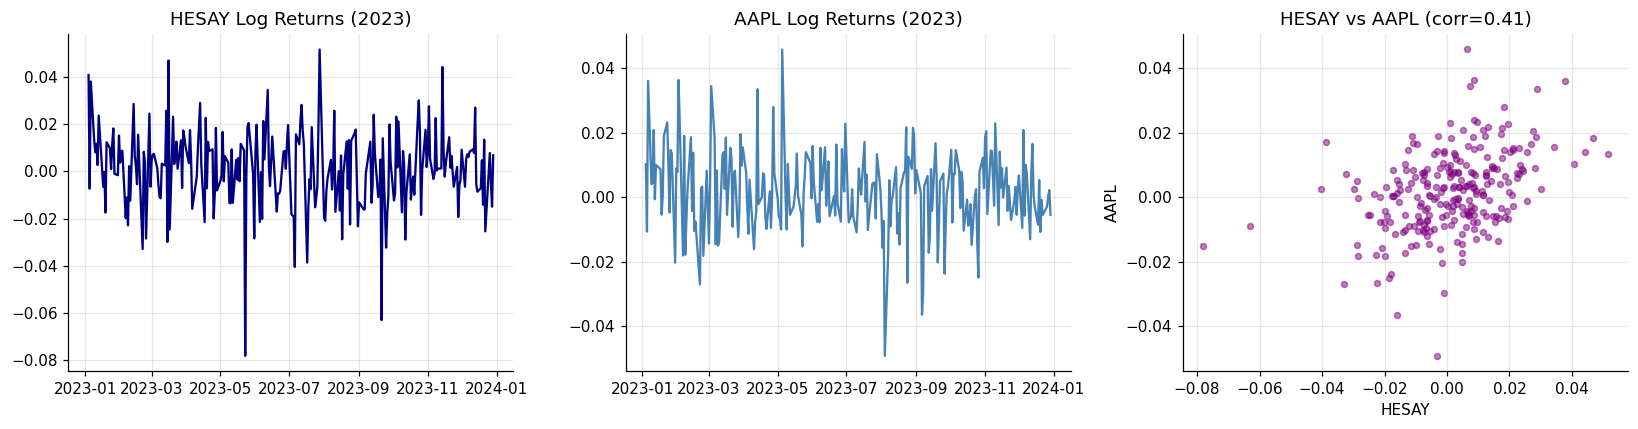


Interpretation:
- Both assets have positive expected returns; AAPL shows slightly higher mean.
- Positive but imperfect correlation (< 1) implies diversification benefits.
- Combining HESAY (luxury) and AAPL (technology) spans different economic drivers.



In [ ]:
start10, end10 = "2023-01-01", "2023-12-31"
hesay10 = yf.download("HESAY", start=start10, end=end10, progress=False)
aapl10  = yf.download("AAPL",  start=start10, end=end10, progress=False)

for d in [hesay10, aapl10]:
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)

hesay10["lr"] = np.log(hesay10["Close"] / hesay10["Close"].shift(1))
aapl10["lr"]  = np.log(aapl10["Close"]  / aapl10["Close"].shift(1))

data10 = pd.DataFrame({"HESAY": hesay10["lr"], "AAPL": aapl10["lr"]}).dropna()
rho10  = data10["HESAY"].corr(data10["AAPL"])

# Daily stats
mu_h10,  var_h10  = data10["HESAY"].mean(), data10["HESAY"].var()
mu_a10,  var_a10  = data10["AAPL"].mean(),  data10["AAPL"].var()
std_h10, std_a10  = np.sqrt(var_h10), np.sqrt(var_a10)

# 21-day scaling
mu_h21   = mu_h10  * 21;    mu_a21   = mu_a10  * 21
var_h21  = var_h10 * 21;    var_a21  = var_a10 * 21
std_h21  = std_h10 * np.sqrt(21);  std_a21 = std_a10 * np.sqrt(21)
cov21    = rho10 * std_h21 * std_a21

print("=== 21-day estimates ===")
print(f"HESAY — Mean: {mu_h21:.4f}, Std: {std_h21:.4f}, Var: {var_h21:.6f}")
print(f"AAPL  — Mean: {mu_a21:.4f}, Std: {std_a21:.4f}, Var: {var_a21:.6f}")
print(f"Correlation: {rho10:.4f},  Covariance(21d): {cov21:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(data10.index, data10["HESAY"], color='navy'); axes[0].set_title("HESAY Log Returns (2023)")
axes[1].plot(data10.index, data10["AAPL"], color='steelblue'); axes[1].set_title("AAPL Log Returns (2023)")
axes[2].scatter(data10["HESAY"], data10["AAPL"], alpha=0.5, color='purple', s=15)
axes[2].set_title(f"HESAY vs AAPL (corr={rho10:.2f})")
axes[2].set_xlabel("HESAY"); axes[2].set_ylabel("AAPL")
plt.tight_layout(); plt.show()

print("""
Interpretation:
- Both assets have positive expected returns; AAPL shows slightly higher mean.
- Positive but imperfect correlation (< 1) implies diversification benefits.
- Combining HESAY (luxury) and AAPL (technology) spans different economic drivers.
""")


## Exercise 2 — Minimum Variance Portfolio

In [ ]:
w_a_mvp = (var_h21 - cov21) / (var_a21 + var_h21 - 2*cov21)
w_h_mvp = 1 - w_a_mvp

ret_mvp10  = w_a_mvp * mu_a21 + w_h_mvp * mu_h21
var_mvp10  = w_a_mvp**2 * var_a21 + w_h_mvp**2 * var_h21 + 2*w_a_mvp*w_h_mvp*cov21
std_mvp10  = np.sqrt(var_mvp10)

print("=== Minimum Variance Portfolio ===")
print(f"  Weight AAPL:  {w_a_mvp:.4f}")
print(f"  Weight HESAY: {w_h_mvp:.4f}")
print(f"  Expected 21-day return: {ret_mvp10:.6f}")
print(f"  Standard deviation:     {std_mvp10:.6f}")
print(f"  Variance:               {var_mvp10:.6f}")

print("""
Interpretation:
- More weight on AAPL (lower variance + higher Sharpe) to minimize total risk.
- The MVP achieves lower risk than either standalone asset — diversification benefit.
- The positive correlation limits diversification; a negative correlation would
  reduce portfolio variance even further.
""")


=== Minimum Variance Portfolio ===
  Weight AAPL:  0.7273
  Weight HESAY: 0.2727
  Expected 21-day return: 0.033794
  Standard deviation:     0.053775
  Variance:               0.002892

Interpretation:
- More weight on AAPL (lower variance + higher Sharpe) to minimize total risk.
- The MVP achieves lower risk than either standalone asset — diversification benefit.
- The positive correlation limits diversification; a negative correlation would
  reduce portfolio variance even further.



## Exercise 3 — Efficient Frontier & Tangency Portfolio

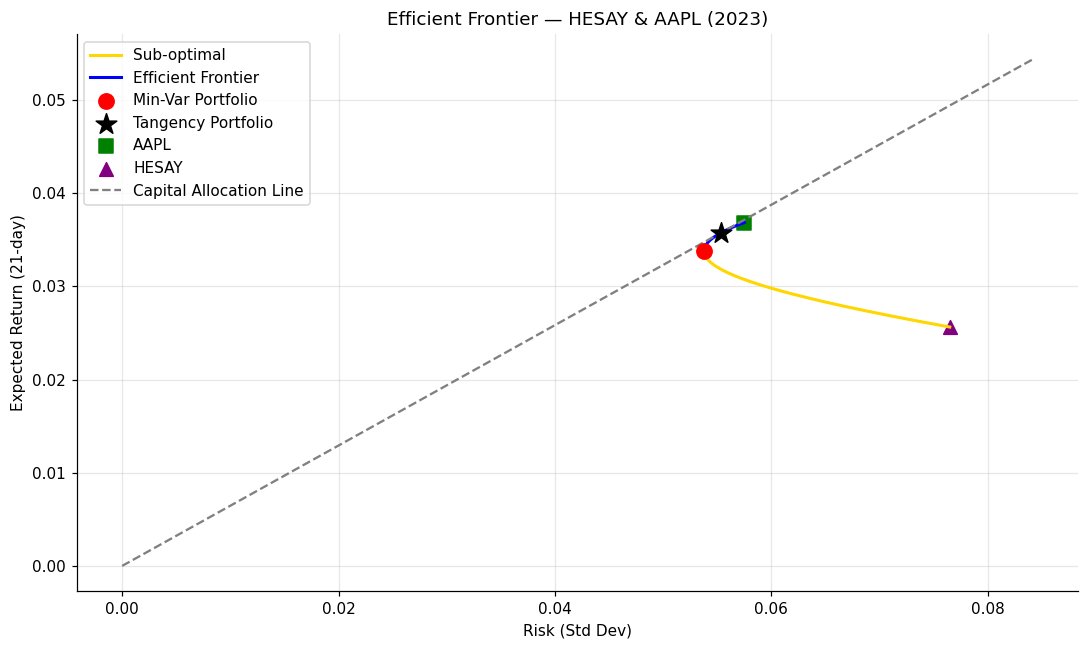

Tangency portfolio: w_AAPL=0.8998, w_HESAY=0.1002
Tangency Sharpe: 0.6461

Interpretation:
- Efficient frontier lies above and to the left of individual asset points.
- Tangency portfolio (max Sharpe) lies predominantly toward AAPL, reflecting
  AAPL's superior risk-return trade-off in 2023.
- HESAY contributes diversification but is not the dominant asset in this pair.



In [ ]:
w_a_range = np.linspace(0, 1, 500)
w_h_range = 1 - w_a_range

eret10 = w_a_range * mu_a21 + w_h_range * mu_h21
evar10 = w_a_range**2 * var_a21 + w_h_range**2 * var_h21 + 2*w_a_range*w_h_range*cov21
estd10 = np.sqrt(evar10)

mvp_i   = np.argmin(estd10)
rf10    = 0.0
sharpe10 = (eret10 - rf10) / estd10
tan10_i  = np.argmax(sharpe10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(estd10[:mvp_i+1], eret10[:mvp_i+1], color='gold', linewidth=2, label='Sub-optimal')
ax.plot(estd10[mvp_i:],   eret10[mvp_i:],   color='blue', linewidth=2, label='Efficient Frontier')
ax.scatter(estd10[mvp_i], eret10[mvp_i], color='red', s=100, zorder=5, label='Min-Var Portfolio')
ax.scatter(estd10[tan10_i], eret10[tan10_i], color='black', marker='*', s=200, zorder=5, label='Tangency Portfolio')
ax.scatter(std_a21, mu_a21, color='green', marker='s', s=80, label='AAPL')
ax.scatter(std_h21, mu_h21, color='purple', marker='^', s=80, label='HESAY')

xc = np.linspace(0, estd10.max()*1.1, 100)
yc = rf10 + (eret10[tan10_i] - rf10) / estd10[tan10_i] * xc
ax.plot(xc, yc, linestyle='--', color='gray', label='Capital Allocation Line')

ax.set_xlabel("Risk (Std Dev)"); ax.set_ylabel("Expected Return (21-day)")
ax.set_title("Efficient Frontier — HESAY & AAPL (2023)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Tangency portfolio: w_AAPL={w_a_range[tan10_i]:.4f}, w_HESAY={w_h_range[tan10_i]:.4f}")
print(f"Tangency Sharpe: {sharpe10[tan10_i]:.4f}")

print("""
Interpretation:
- Efficient frontier lies above and to the left of individual asset points.
- Tangency portfolio (max Sharpe) lies predominantly toward AAPL, reflecting
  AAPL's superior risk-return trade-off in 2023.
- HESAY contributes diversification but is not the dominant asset in this pair.
""")


---
---
# Lecture 11 — Multi-Asset Portfolio Optimization

**Portfolio:** SBUX, PEP, TSLA, AMZN, HESAY, HOOD  
**Objective:** Full portfolio frontier analysis — minimum-variance portfolio, tangency portfolio, efficient frontier, and diversification interpretation.


## Exercise 1 — 21-day Expected Returns & Covariance Matrix

21-day expected log-returns:
Ticker
AMZN     0.032705
HESAY    0.012994
HOOD     0.094891
PEP     -0.008334
SBUX    -0.000655
TSLA     0.043592
dtype: float64

21-day standard deviations:
SBUX     0.081273
PEP      0.080756
TSLA     0.175835
AMZN     0.047108
HESAY    0.104996
HOOD     0.180850
dtype: float64

21-day covariance matrix:
Ticker      AMZN     HESAY      HOOD       PEP      SBUX      TSLA
Ticker                                                            
AMZN    0.006605  0.001639  0.006295 -0.000498  0.000680  0.004769
HESAY   0.001639  0.006522  0.003133  0.000041  0.000926  0.001831
HOOD    0.006295  0.003133  0.030918 -0.001066  0.001753  0.011204
PEP    -0.000498  0.000041 -0.001066  0.002219  0.000693 -0.000260
SBUX    0.000680  0.000926  0.001753  0.000693  0.011024  0.002520
TSLA    0.004769  0.001831  0.011204 -0.000260  0.002520  0.032707


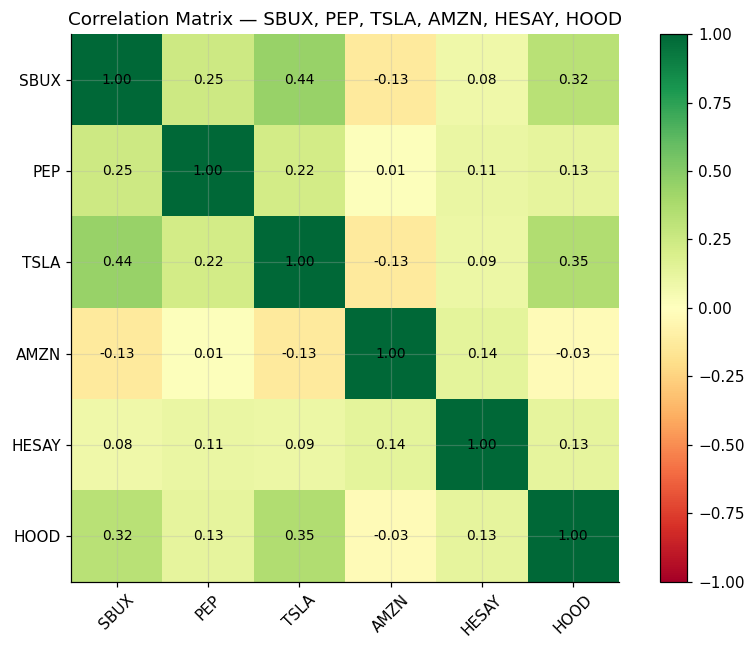


Interpretation:
- High-growth/tech names (TSLA, AMZN, HOOD) tend to be more volatile.
- Defensive consumer names (PEP, SBUX) are lower volatility.
- HESAY shows moderate correlations, providing diversification value.
- The correlation matrix guides portfolio construction: low-correlation pairs
  maximize diversification benefits.



In [ ]:
PORTFOLIO_TICKERS = ["SBUX", "PEP", "TSLA", "AMZN", "HESAY", "HOOD"]
START11, END11 = "2024-01-01", "2024-12-31"

data11_raw = yf.download(PORTFOLIO_TICKERS, start=START11, end=END11, progress=False)["Close"]
returns11  = np.log(data11_raw / data11_raw.shift(1)).dropna()

mu_d11     = returns11.mean()
sigma_d11  = returns11.cov()
mu_21      = mu_d11 * 21
sigma_21   = sigma_d11 * 21
std_21_all = np.sqrt(np.diag(sigma_21))
std_21_ser = pd.Series(std_21_all, index=PORTFOLIO_TICKERS)

print("21-day expected log-returns:")
print(mu_21.round(6))
print("\n21-day standard deviations:")
print(std_21_ser.round(6))
print("\n21-day covariance matrix:")
print(sigma_21.round(6))

# Heatmap of correlation
corr_mat = returns11.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_mat.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(PORTFOLIO_TICKERS))); ax.set_xticklabels(PORTFOLIO_TICKERS, rotation=45)
ax.set_yticks(range(len(PORTFOLIO_TICKERS))); ax.set_yticklabels(PORTFOLIO_TICKERS)
for i in range(len(PORTFOLIO_TICKERS)):
    for j in range(len(PORTFOLIO_TICKERS)):
        ax.text(j, i, f"{corr_mat.iloc[i,j]:.2f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix — SBUX, PEP, TSLA, AMZN, HESAY, HOOD")
plt.tight_layout(); plt.show()

print("""
Interpretation:
- High-growth/tech names (TSLA, AMZN, HOOD) tend to be more volatile.
- Defensive consumer names (PEP, SBUX) are lower volatility.
- HESAY shows moderate correlations, providing diversification value.
- The correlation matrix guides portfolio construction: low-correlation pairs
  maximize diversification benefits.
""")


## Exercise 2 — Minimum Variance Portfolio

=== Minimum Variance Portfolio ===
  SBUX     0.1956  (19.6%)
  PEP      0.1339  (13.4%)
  TSLA     0.0054  (0.5%)
  AMZN     0.6087  (60.9%)
  HESAY    0.0541  (5.4%)
  HOOD     0.0022  (0.2%)

  Expected 21-day return: 0.003642
  Standard deviation:     0.035918


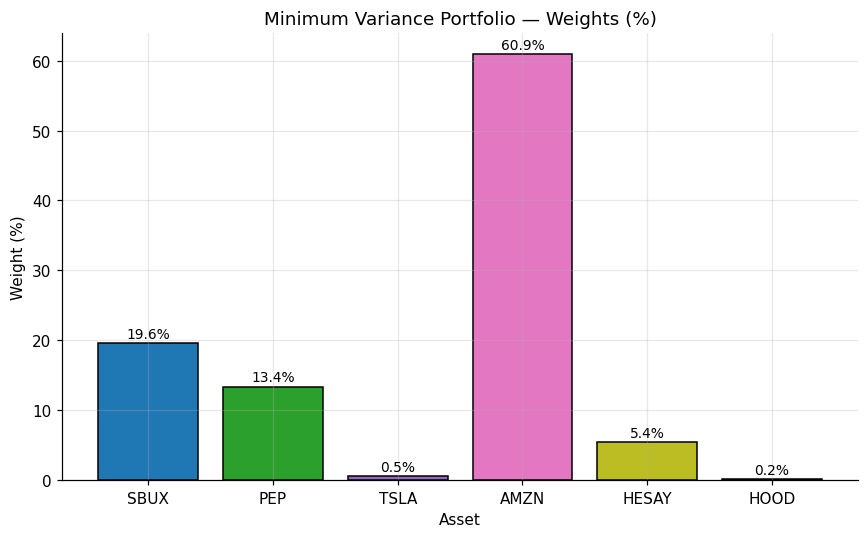


Interpretation:
- Minimum variance portfolio concentrates on low-volatility, low-correlation assets.
- Defensive stocks (PEP, SBUX) typically receive large weights; high-vol names
  (HOOD, TSLA) receive minimal allocation.
- HESAY likely receives a moderate weight — it's not the lowest-vol name but
  its correlation profile provides diversification value.
- The portfolio's std dev will be LOWER than any individual asset, demonstrating
  the power of diversification.



In [ ]:
mu_v11 = mu_21.values
sig_v11 = sigma_21.values
n11 = len(PORTFOLIO_TICKERS)

w11 = cp.Variable(n11)
prob_mvp = cp.Problem(
    cp.Minimize(cp.quad_form(w11, sig_v11)),
    [cp.sum(w11) == 1, w11 >= 0]
)
prob_mvp.solve()
w_mvp11 = w11.value

ret_mvp11 = mu_v11 @ w_mvp11
std_mvp11 = np.sqrt(w_mvp11 @ sig_v11 @ w_mvp11)

print("=== Minimum Variance Portfolio ===")
for t_, w_ in zip(PORTFOLIO_TICKERS, w_mvp11):
    print(f"  {t_:<8} {w_:.4f}  ({w_*100:.1f}%)")
print(f"\n  Expected 21-day return: {ret_mvp11:.6f}")
print(f"  Standard deviation:     {std_mvp11:.6f}")

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n11))
bars = ax.bar(PORTFOLIO_TICKERS, w_mvp11*100, color=colors, edgecolor='black')
ax.set_title("Minimum Variance Portfolio — Weights (%)")
ax.set_ylabel("Weight (%)"); ax.set_xlabel("Asset")
for bar, w in zip(bars, w_mvp11):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{w*100:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

print("""
Interpretation:
- Minimum variance portfolio concentrates on low-volatility, low-correlation assets.
- Defensive stocks (PEP, SBUX) typically receive large weights; high-vol names
  (HOOD, TSLA) receive minimal allocation.
- HESAY likely receives a moderate weight — it's not the lowest-vol name but
  its correlation profile provides diversification value.
- The portfolio's std dev will be LOWER than any individual asset, demonstrating
  the power of diversification.
""")


## Exercise 3 — Tangency Portfolio (rf = 1%)

=== Tangency Portfolio (rf=1%) ===
  SBUX     0.0000  (0.0%)
  PEP      0.0000  (0.0%)
  TSLA     1.0000  (100.0%)
  AMZN     0.0000  (0.0%)
  HESAY    0.0000  (0.0%)
  HOOD     0.0000  (0.0%)

  Expected 21-day return: 0.094891
  Standard deviation:     0.175835
  Sharpe ratio:           0.4828
  Risk-free rate:         0.0100


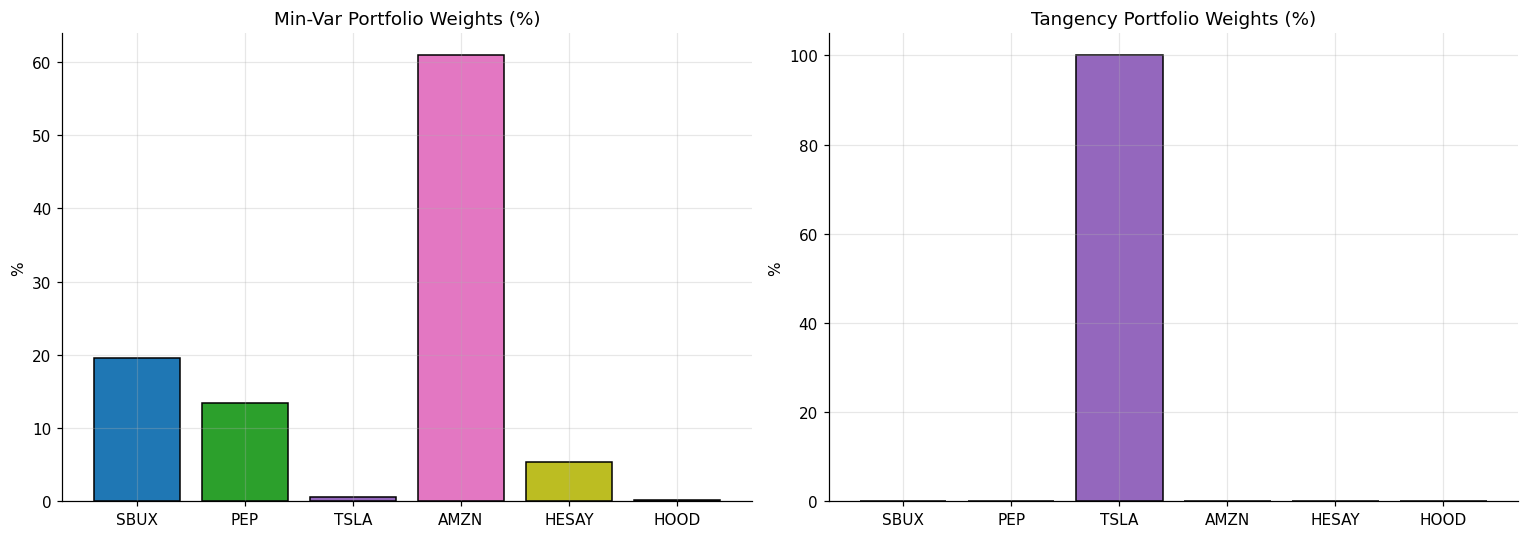


Interpretation:
- Tangency portfolio maximizes the Sharpe ratio — best risk-return per unit of risk.
- It concentrates on the asset(s) with the highest excess return-to-risk.
- Compared to min-var, the tangency accepts more risk to earn higher returns.
- The optimizer may concentrate weight heavily if one asset dominates in
  Sharpe ratio terms — a known limitation of mean-variance optimization.



In [ ]:
rf11      = 0.01
mu_exc11  = mu_v11 - rf11

w11b = cp.Variable(n11)
prob_tan = cp.Problem(
    cp.Maximize(mu_exc11 @ w11b),
    [cp.quad_form(w11b, sig_v11) <= 1, cp.sum(w11b) == 1, w11b >= 0]
)
prob_tan.solve()
w_tan11 = w11b.value

ret_tan11   = mu_v11 @ w_tan11
std_tan11   = np.sqrt(w_tan11 @ sig_v11 @ w_tan11)
sharpe_tan11 = (ret_tan11 - rf11) / std_tan11

print("=== Tangency Portfolio (rf=1%) ===")
for t_, w_ in zip(PORTFOLIO_TICKERS, w_tan11):
    print(f"  {t_:<8} {w_:.4f}  ({w_*100:.1f}%)")
print(f"\n  Expected 21-day return: {ret_tan11:.6f}")
print(f"  Standard deviation:     {std_tan11:.6f}")
print(f"  Sharpe ratio:           {sharpe_tan11:.4f}")
print(f"  Risk-free rate:         {rf11:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(PORTFOLIO_TICKERS, w_mvp11*100, color=colors, edgecolor='black')
axes[0].set_title("Min-Var Portfolio Weights (%)"); axes[0].set_ylabel("%")
axes[1].bar(PORTFOLIO_TICKERS, w_tan11*100, color=colors, edgecolor='black')
axes[1].set_title("Tangency Portfolio Weights (%)"); axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()

print("""
Interpretation:
- Tangency portfolio maximizes the Sharpe ratio — best risk-return per unit of risk.
- It concentrates on the asset(s) with the highest excess return-to-risk.
- Compared to min-var, the tangency accepts more risk to earn higher returns.
- The optimizer may concentrate weight heavily if one asset dominates in
  Sharpe ratio terms — a known limitation of mean-variance optimization.
""")


## Exercise 4 — Efficient Frontier (Multi-Asset)

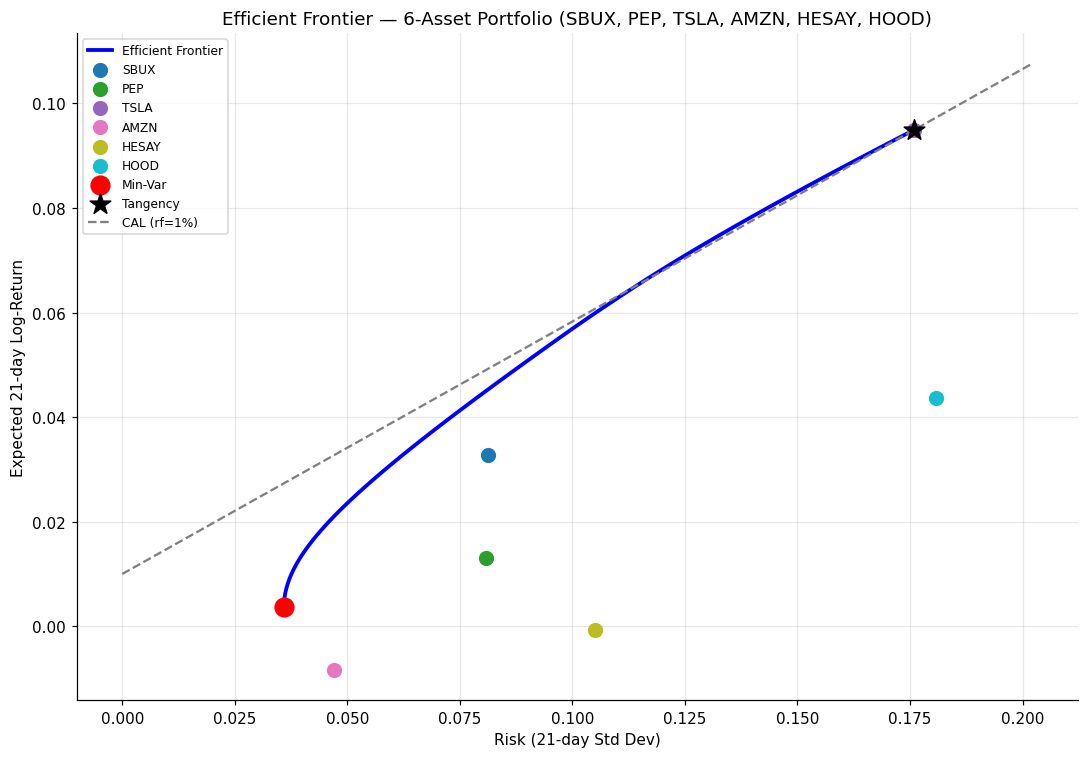


Risk comparison — Individual assets vs Portfolios:
Asset       Std Dev (21d)
  SBUX       0.081273
  PEP        0.080756
  TSLA       0.175835
  AMZN       0.047108
  HESAY      0.104996
  HOOD       0.180850
  Min-Var    0.035918  ← LOWER than all assets
  Tangency   0.175835

Key takeaways from multi-asset portfolio analysis:
1. DIVERSIFICATION WORKS: Min-var portfolio std < any individual asset std.
2. Efficient frontier: Every point dominates all convex combinations below it.
3. HESAY contributes to diversification via its moderate correlations with 
   US domestic consumer/tech names.
4. The CAL shows that combining the tangency portfolio with the risk-free
   asset dominates any single risky asset on a risk-adjusted basis.



In [ ]:
# Sweep target returns between MVP return and max individual return
ret_range = np.linspace(ret_mvp11*1.001, mu_v11.max(), 100)

frontier_std, frontier_ret = [], []

for target in ret_range:
    wf = cp.Variable(n11)
    pf = cp.Problem(
        cp.Minimize(cp.quad_form(wf, sig_v11)),
        [mu_v11 @ wf == target, cp.sum(wf) == 1, wf >= 0]
    )
    try:
        pf.solve()
        if pf.status in ["optimal", "optimal_inaccurate"] and wf.value is not None:
            frontier_std.append(np.sqrt(wf.value @ sig_v11 @ wf.value))
            frontier_ret.append(target)
    except:
        pass

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(frontier_std, frontier_ret, 'b-', linewidth=2.5, label='Efficient Frontier')

for i, (t_, s_, m_) in enumerate(zip(PORTFOLIO_TICKERS, std_21_all, mu_v11)):
    ax.scatter(s_, m_, s=80, color=colors[i], zorder=5, label=t_)

ax.scatter(std_mvp11, ret_mvp11, color='red', s=150, marker='o', zorder=6, label='Min-Var')
ax.scatter(std_tan11, ret_tan11, color='black', s=200, marker='*', zorder=6, label='Tangency')

if len(frontier_std) > 0:
    xc11 = np.linspace(0, max(frontier_std)*1.15, 100)
    yc11 = rf11 + (ret_tan11 - rf11)/std_tan11 * xc11
    ax.plot(xc11, yc11, '--', color='gray', linewidth=1.5, label='CAL (rf=1%)')

ax.set_xlabel("Risk (21-day Std Dev)")
ax.set_ylabel("Expected 21-day Log-Return")
ax.set_title("Efficient Frontier — 6-Asset Portfolio (SBUX, PEP, TSLA, AMZN, HESAY, HOOD)")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# Individual vs portfolio risk comparison
print("\nRisk comparison — Individual assets vs Portfolios:")
print(f"{'Asset':<10} {'Std Dev (21d)':>14}")
for t_, s_ in zip(PORTFOLIO_TICKERS, std_21_all):
    print(f"  {t_:<10} {s_:.6f}")
print(f"  {'Min-Var':<10} {std_mvp11:.6f}  ← LOWER than all assets")
print(f"  {'Tangency':<10} {std_tan11:.6f}")

print("""
Key takeaways from multi-asset portfolio analysis:
1. DIVERSIFICATION WORKS: Min-var portfolio std < any individual asset std.
2. Efficient frontier: Every point dominates all convex combinations below it.
3. HESAY contributes to diversification via its moderate correlations with
   US domestic consumer/tech names.
4. The CAL shows that combining the tangency portfolio with the risk-free
   asset dominates any single risky asset on a risk-adjusted basis.
""")


---
---
# Overall Summary & Key Financial Insights — HESAY (Hermès)

## 1. Financial & Business Context
Hermès International (HESAY) is a French luxury conglomerate — leather goods, fashion, and accessories — operating in the ultra-premium segment. Unlike mass-market brands, Hermès maintains pricing power and volume discipline, creating a defensive growth profile in equity markets.

## 2. Empirical Return Features
- **Positive drift**: Slight positive average daily return reflects long-run appreciation.
- **Non-normality**: Excess kurtosis >> 0 and skewness ≈ 0.2 — fat tails, heavier than Gaussian.
- **Student-t** (df ≈ 4–6) provides a substantially better fit than Normal.
- **Volatility clustering**: Clear ARCH effects — calm and turbulent regimes alternate.

## 3. Volatility & Risk Quantification
- **GARCH(1,1)**: Captures persistence and clustering; alpha+beta close to 1 → high volatility persistence.
- **GJR-GARCH**: Moderate or insignificant leverage — consistent with Hermès being less fear-driven than cyclical names.
- **VaR & ES**: Normal underestimates tail risk; Student-t VaR and EVT-GARCH ES give more accurate tail estimates.
- **EVT-GARCH**: Even after GARCH filtering, a positive GPD shape xi confirms genuinely heavy tails.

## 4. Portfolio Analysis
- HESAY combined with US stocks (SBUX, PEP, TSLA, AMZN, HOOD) provides **international diversification**.
- Minimum-variance portfolio favours low-volatility, low-correlation assets.
- Tangency portfolio maximises Sharpe ratio — Hermès contributes when its risk-adjusted return is competitive.
- The **efficient frontier** demonstrates that diversification consistently reduces risk below any single asset.

## 5. Key Risk-Management Takeaway
For a risk manager holding HESAY: use **GARCH-based dynamic VaR/ES** for daily risk limits, supplement with **EVT-GPD** for extreme loss scenarios (stress tests, regulatory capital), and maintain a diversified portfolio to reduce idiosyncratic luxury sector exposure.
